In [15]:
# Imports


import os
import sys
import io
import json
import math
import time
import random
import shutil
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

import torchvision.transforms as transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve
)

import timm
from facenet_pytorch import MTCNN

print("Imported successfully")

Imported successfully


In [17]:
# Reproducibility + runtime mode


SEED = 42
REPRO_MODE = True   


# Global seeds

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# Determinism controls

if REPRO_MODE:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
else:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


# Matmul precision (Ampere+ optimization)

torch.set_float32_matmul_precision("high")


# Device

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Environment logging 

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
    print("cuDNN:", torch.backends.cudnn.version())

print("Torch version:", torch.__version__)
print("NumPy version:", np.__version__)
print("Reproducibility mode:", REPRO_MODE)

Device: cuda
GPU: NVIDIA RTX A1000 Laptop GPU
CUDA: 12.6
cuDNN: 91002
Torch version: 2.11.0+cu126
NumPy version: 1.26.4
Reproducibility mode: True


In [22]:
# Configuration (multi-domain)


CONFIG = {
    
    # Reproducibility / runtime
    "seed": SEED,
    "repro_mode": REPRO_MODE,


    # Input / image pipeline    
    "image_size": 224,
    "frames_per_video": 8,
    "debug_mode": False,
    "face_conf_threshold": 0.90,
    "jpeg_min_quality": 30,
    "jpeg_max_quality": 95,

    
    # Split design
    # IMPORTANT:
    # FF++ and Celeb-DF must be split at RAW VIDEO level
    # before face extraction to avoid leakage.    
    "train_ratio": 0.80,
    "val_ratio": 0.10,
    "test_ratio": 0.10,

    # Optional caps for controlled experiments.
    # Set to None to use all available videos after filtering.
    "max_videos_per_domain_real": None,
    "max_videos_per_domain_fake": None,

    
    # Training    
    "batch_size": 24,
    "grad_accum_steps": 2,
    "epochs_stage1": 15,
    "epochs_stage2": 35,
    "lr_stage1": 3e-4,
    "lr_stage2": 5e-5,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,

    
    # Stage 2 fine-tuning    
    "unfreeze_blocks": 3,   # unfreeze last N backbone blocks
    "load_best_stage1_before_stage2": True,

    
    # DataLoader / GPU efficiency    
    "num_workers": 0,
    "amp": True,
    "pin_memory": True,
    "persistent_workers": False,
    "prefetch_factor": 2,


    
    # Final controlled caps    
    "final_ffpp_real_cap": 1000,
    "final_ffpp_fake_per_method_cap": 1000,
    "final_celeb_real_cap": 890,
    "final_celeb_fake_cap": 890,
    "final_gan_real_cap": 7120,
    "final_gan_fake_cap": 7120,
    
    
    
    # Evaluation / threshold tuning    
    "threshold_metric": "f1",
    "threshold_grid_size": 1001,
    "save_validation_curves": True,
    "save_test_curves": True,

    
    # Reporting    
    "save_csv": True,
    "save_json": True,
    "save_figures": True,
    "save_checkpoints": True,
}


# Paths
ROOT = Path("./Datasets/Raw-datasets")
PROJECT_OUT = Path("./outputs_methodx_final_1")

RAW_FFPP = ROOT / "FaceForensicsPP"
RAW_CELEBDF = ROOT / "CelebDF" / "Celeb-DF-v2"
RAW_GAN = ROOT / "GANFaces"
RAW_FFHQ = RAW_GAN / "FFHQ" / "real"
RAW_STYLEGAN = RAW_GAN / "StyleGAN" / "fake"

OUT_PREP = PROJECT_OUT / "preprocessing"
OUT_PROCESSED = PROJECT_OUT / "processed"
OUT_MANIFESTS = PROJECT_OUT / "manifests"
OUT_RESULTS = PROJECT_OUT / "results"
OUT_FIGURES = OUT_RESULTS / "figures"
OUT_TABLES = OUT_RESULTS / "tables"
OUT_CHECKPOINTS = PROJECT_OUT / "checkpoints"
OUT_LOGS = PROJECT_OUT / "logs"

for p in [
    PROJECT_OUT,
    OUT_PREP,
    OUT_PROCESSED,
    OUT_MANIFESTS,
    OUT_RESULTS,
    OUT_FIGURES,
    OUT_TABLES,
    OUT_CHECKPOINTS,
    OUT_LOGS,
]:
    p.mkdir(parents=True, exist_ok=True)


# Processed output roots
OUTPUT_FFPP = OUT_PROCESSED / "FaceForensicsPP_processed"
OUTPUT_CELEB = OUT_PROCESSED / "CelebDF_processed"
OUTPUT_GAN = OUT_PROCESSED / "GANFaces_processed"


# Standard artifact paths
ARTIFACTS = {
    "config_json": OUT_RESULTS / "config.json",

    "ffpp_split_manifest": OUT_MANIFESTS / "ffpp_video_splits.json",
    "celebdf_split_manifest": OUT_MANIFESTS / "celebdf_video_splits.json",
    "gan_split_manifest": OUT_MANIFESTS / "gan_image_splits.json",

    "preprocess_summary_json": OUT_PREP / "preprocessing_summary.json",
    "master_manifest_csv": OUT_MANIFESTS / "master_frame_manifest.csv",

    "stage1_history_json": OUT_LOGS / "stage1_history.json",
    "stage2_history_json": OUT_LOGS / "stage2_history.json",

    "best_stage1_ckpt": OUT_CHECKPOINTS / "best_stage1.pt",
    "best_stage2_ckpt": OUT_CHECKPOINTS / "best_stage2.pt",
    "last_stage1_ckpt": OUT_CHECKPOINTS / "last_stage1.pt",
    "last_stage2_ckpt": OUT_CHECKPOINTS / "last_stage2.pt",

    "thresholds_json": OUT_RESULTS / "thresholds.json",
    "val_metrics_json": OUT_RESULTS / "validation_metrics.json",
    "test_metrics_json": OUT_RESULTS / "test_metrics.json",
    "per_domain_test_csv": OUT_TABLES / "per_domain_test_metrics.csv",
    "overall_test_csv": OUT_TABLES / "overall_test_metrics.csv",

    "training_plot_png": OUT_FIGURES / "training_history.png",
    "val_roc_png": OUT_FIGURES / "validation_roc.png",
    "test_roc_png": OUT_FIGURES / "test_roc.png",
    "confusion_matrix_png": OUT_FIGURES / "test_confusion_matrix.png",
}


# Save config as JSON-serializable dict
config_to_save = dict(CONFIG)
config_to_save["paths"] = {
    "ROOT": str(ROOT),
    "PROJECT_OUT": str(PROJECT_OUT),
    "RAW_FFPP": str(RAW_FFPP),
    "RAW_CELEBDF": str(RAW_CELEBDF),
    "RAW_GAN": str(RAW_GAN),
    "RAW_FFHQ": str(RAW_FFHQ),
    "RAW_STYLEGAN": str(RAW_STYLEGAN),
    "OUT_PREP": str(OUT_PREP),
    "OUT_PROCESSED": str(OUT_PROCESSED),
    "OUT_MANIFESTS": str(OUT_MANIFESTS),
    "OUT_RESULTS": str(OUT_RESULTS),
    "OUT_FIGURES": str(OUT_FIGURES),
    "OUT_TABLES": str(OUT_TABLES),
    "OUT_CHECKPOINTS": str(OUT_CHECKPOINTS),
    "OUT_LOGS": str(OUT_LOGS),
}
config_to_save["artifacts"] = {k: str(v) for k, v in ARTIFACTS.items()}

with open(ARTIFACTS["config_json"], "w") as f:
    json.dump(config_to_save, f, indent=2)

print("Project output root:", PROJECT_OUT)
print("Config saved to:", ARTIFACTS["config_json"])

Project output root: outputs_methodx_final_1
Config saved to: outputs_methodx_final_1\results\config.json


In [24]:
# Environment summary (saved log)

env_summary = {
    "python": sys.version.split()[0],
    "pytorch": torch.__version__,
    "numpy": np.__version__,
    "device": str(DEVICE),
    "image_size": CONFIG["image_size"],
    "batch_size": CONFIG["batch_size"],
    "grad_accum_steps": CONFIG["grad_accum_steps"],
    "output_folder": str(PROJECT_OUT),
}

if torch.cuda.is_available():
    env_summary.update({
        "gpu_name": torch.cuda.get_device_name(0),
        "gpu_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "cuda_version": torch.version.cuda,
        "cudnn_version": torch.backends.cudnn.version(),
    })

print("=" * 70)
print("Detection Pipeline")
print("=" * 70)

for k, v in env_summary.items():
    print(f"{k:20}: {v}")

print("=" * 70)


# Save environment summary 

env_path = OUT_LOGS / "environment.json"
with open(env_path, "w") as f:
    json.dump(env_summary, f, indent=2)

print(f"Environment log saved to: {env_path}")

Detection Pipeline
python              : 3.10.20
pytorch             : 2.11.0+cu126
numpy               : 1.26.4
device              : cuda
image_size          : 224
batch_size          : 24
grad_accum_steps    : 2
output_folder       : outputs_methodx_final_1
gpu_name            : NVIDIA RTX A1000 Laptop GPU
gpu_memory_gb       : 4.0
cuda_version        : 12.6
cudnn_version       : 91002
Environment log saved to: outputs_methodx_final_1\logs\environment.json


In [25]:
# Validate raw dataset paths

def count_files_recursive(path, exts=None):
    if not path.exists():
        return 0
    if exts is None:
        return sum(1 for _ in path.rglob("*") if _.is_file())
    return sum(1 for _ in path.rglob("*") if _.suffix.lower() in exts)

raw_paths = {
    "RAW_FFPP": RAW_FFPP,
    "RAW_CELEBDF": RAW_CELEBDF,
    "RAW_FFHQ": RAW_FFHQ,
    "RAW_STYLEGAN": RAW_STYLEGAN,
}

dataset_summary = {}

print("=" * 70)
print("RAW DATASET VALIDATION")
print("=" * 70)

for name, path in raw_paths.items():
    exists = path.exists()
    total_files = count_files_recursive(path)

    dataset_summary[name] = {
        "path": str(path),
        "exists": exists,
        "total_files": total_files,
    }

    print(f"{name:<15} -> Exists: {exists} | Files: {total_files}")

    if exists and total_files == 0:
        print(f"WARNING: {name} is empty!")

print("=" * 70)


# Save dataset validation summary

summary_path = OUT_PREP / "raw_dataset_summary.json"
with open(summary_path, "w") as f:
    json.dump(dataset_summary, f, indent=2)

print(f"Saved dataset summary to: {summary_path}")

RAW DATASET VALIDATION
RAW_FFPP        -> Exists: True | Files: 6003
RAW_CELEBDF     -> Exists: True | Files: 6530
RAW_FFHQ        -> Exists: True | Files: 70000
RAW_STYLEGAN    -> Exists: True | Files: 71763
Saved dataset summary to: outputs_methodx_final_1\preprocessing\raw_dataset_summary.json


In [26]:
# Collection helpers and split utilities


VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv")
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def collect_videos(folder, recursive=False):
    folder = Path(folder)
    if not folder.exists():
        return []
    iterator = folder.rglob("*") if recursive else folder.iterdir()
    return sorted(
        [p for p in iterator if p.is_file() and p.suffix.lower() in VIDEO_EXTS],
        key=lambda x: str(x).lower()
    )


def collect_images(folder, recursive=True):
    folder = Path(folder)
    if not folder.exists():
        return []
    iterator = folder.rglob("*") if recursive else folder.iterdir()
    return sorted(
        [p for p in iterator if p.is_file() and p.suffix.lower() in IMAGE_EXTS],
        key=lambda x: str(x).lower()
    )


def split_list(items, train_ratio, val_ratio, test_ratio, seed=42, deduplicate=True):
    total_ratio = train_ratio + val_ratio + test_ratio
    if not np.isclose(total_ratio, 1.0):
        raise ValueError(f"Split ratios must sum to 1.0, got {total_ratio}")

    items = list(items)

    if deduplicate:
        seen = set()
        deduped = []
        for x in items:
            key = str(x)
            if key not in seen:
                seen.add(key)
                deduped.append(x)
        items = deduped

    if len(items) == 0:
        return {"train": [], "val": [], "test": []}

    rng = random.Random(seed)
    rng.shuffle(items)

    total = len(items)
    n_train = int(round(train_ratio * total))
    n_val = int(round(val_ratio * total))

    # ensure exact partition without loss/overflow
    n_train = min(n_train, total)
    n_val = min(n_val, total - n_train)
    n_test = total - n_train - n_val

    train_items = items[:n_train]
    val_items = items[n_train:n_train + n_val]
    test_items = items[n_train + n_val:n_train + n_val + n_test]

    assert len(train_items) + len(val_items) + len(test_items) == total

    return {
        "train": train_items,
        "val": val_items,
        "test": test_items
    }


def _json_safe(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    return obj


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(_json_safe(obj), f, indent=2, ensure_ascii=False)


def save_df(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8")

In [27]:
# Face extractor

class FaceExtractor:
    def __init__(self, image_size=224, device="cpu", conf_threshold=0.90, min_face_size=20):
        self.image_size = image_size
        self.device = device
        self.conf_threshold = conf_threshold
        self.min_face_size = min_face_size

        self.mtcnn = MTCNN(
            image_size=image_size,
            margin=0,
            post_process=False,
            keep_all=True,
            device=device
        )

    def extract_face(self, frame_rgb):
        """
        Args:
            frame_rgb: numpy array (H, W, 3), RGB

        Returns:
            face tensor of shape (3, image_size, image_size), or None
        """
        if frame_rgb is None:
            return None

        if not isinstance(frame_rgb, np.ndarray):
            return None

        if frame_rgb.ndim != 3 or frame_rgb.shape[2] != 3:
            return None

        h, w = frame_rgb.shape[:2]
        if h < 2 or w < 2:
            return None

        img = Image.fromarray(frame_rgb)

        try:
            boxes, probs = self.mtcnn.detect(img)
        except Exception:
            return None

        if boxes is None or probs is None or len(boxes) == 0:
            return None

        boxes = np.asarray(boxes, dtype=np.float32)
        probs = np.asarray(probs, dtype=np.float32)

        valid_mask = probs >= self.conf_threshold
        if not np.any(valid_mask):
            return None

        valid_boxes = boxes[valid_mask]

        # clamp boxes to valid image region
        valid_boxes[:, 0] = np.clip(valid_boxes[:, 0], 0, w - 1)
        valid_boxes[:, 1] = np.clip(valid_boxes[:, 1], 0, h - 1)
        valid_boxes[:, 2] = np.clip(valid_boxes[:, 2], 0, w - 1)
        valid_boxes[:, 3] = np.clip(valid_boxes[:, 3], 0, h - 1)

        widths = valid_boxes[:, 2] - valid_boxes[:, 0]
        heights = valid_boxes[:, 3] - valid_boxes[:, 1]

        size_mask = (widths >= self.min_face_size) & (heights >= self.min_face_size)
        if not np.any(size_mask):
            return None

        valid_boxes = valid_boxes[size_mask]
        widths = valid_boxes[:, 2] - valid_boxes[:, 0]
        heights = valid_boxes[:, 3] - valid_boxes[:, 1]
        areas = widths * heights

        best_box = valid_boxes[np.argmax(areas)].reshape(1, 4)

        try:
            face = self.mtcnn.extract(img, best_box, save_path=None)
        except Exception:
            return None

        if face is None:
            return None

        # MTCNN.extract may return shape (1, 3, H, W)
        if isinstance(face, torch.Tensor):
            if face.ndim == 4 and face.shape[0] == 1:
                face = face[0]
            if face.ndim != 3:
                return None
            return face

        return None

In [28]:
# Frame extraction from video


def _stable_int_from_string(s: str) -> int:
    h = hashlib.sha256(s.encode("utf-8")).hexdigest()
    return int(h[:16], 16) % (2**32)


def extract_frames(video_path, frames_per_video=8, seed=42, allow_short_videos=True):
    """
    Deterministically sample frames across a video timeline.

    Args:
        video_path: path to input video
        frames_per_video: target number of sampled frames
        seed: global seed
        allow_short_videos: if True, return up to total_frames frames for short videos

    Returns:
        List of RGB numpy arrays
    """
    video_path = Path(video_path)
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        cap.release()
        return []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return []

    if total_frames < frames_per_video:
        if not allow_short_videos:
            cap.release()
            return []
        target_count = total_frames
    else:
        target_count = frames_per_video

    # deterministic per-video RNG
    video_seed = (seed + _stable_int_from_string(str(video_path.resolve()))) % (2**32)
    rng = np.random.default_rng(video_seed)

    # valid frame indices are [0, total_frames - 1]
    boundaries = np.linspace(0, total_frames - 1, target_count + 1, dtype=int)

    selected_indices = []
    for i in range(target_count):
        start = int(boundaries[i])
        end = int(boundaries[i + 1])

        if end <= start:
            frame_idx = start
        else:
            frame_idx = int(rng.integers(start, end + 1))

        selected_indices.append(frame_idx)

    # avoid duplicate frame reads when bins collapse
    selected_indices = sorted(set(selected_indices))

    selected_frames = []
    for frame_idx in selected_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ret, frame = cap.read()
        if not ret or frame is None:
            continue

        try:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        except Exception:
            continue

        selected_frames.append(frame)

    cap.release()
    return selected_frames

In [29]:
# Save helpers

def _deterministic_jpeg_quality(save_path, qmin=None, qmax=None):
    if qmin is None:
        qmin = CONFIG["jpeg_min_quality"]
    if qmax is None:
        qmax = CONFIG["jpeg_max_quality"]

    if qmin == qmax:
        return int(qmin)

    span = int(qmax) - int(qmin) + 1
    key = str(Path(save_path).resolve())
    offset = _stable_int_from_string(key) % span
    return int(qmin + offset)


def save_face(face_tensor, save_path, jpeg_quality=None):
    """
    Save a face tensor as deterministic JPEG.

    Args:
        face_tensor: torch.Tensor of shape (3,H,W) or (1,H,W)
        save_path: output file path
        jpeg_quality: optional explicit JPEG quality

    Returns:
        bool
    """
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        if face_tensor is None or not isinstance(face_tensor, torch.Tensor):
            return False

        face_np = face_tensor.detach().cpu().float().numpy()

        if face_np.ndim != 3 or face_np.shape[0] not in (1, 3):
            return False

        face_np = np.transpose(face_np, (1, 2, 0))

        # normalize into uint8 image space
        if face_np.min() >= 0.0 and face_np.max() <= 1.0:
            face_np = face_np * 255.0
        elif face_np.min() >= -1.0 and face_np.max() <= 1.0:
            face_np = (face_np + 1.0) * 0.5 * 255.0

        face_np = np.clip(face_np, 0, 255).astype(np.uint8)

        if face_np.shape[2] == 1:
            face_np = np.repeat(face_np, 3, axis=2)

        if jpeg_quality is None:
            jpeg_quality = _deterministic_jpeg_quality(save_path)

        Image.fromarray(face_np, mode="RGB").save(
            save_path,
            format="JPEG",
            quality=int(jpeg_quality),
            subsampling=0,
            optimize=False
        )
        return True

    except Exception as e:
        print(f"[WARN] Failed to save face: {save_path} | {e}")
        return False


def save_pil_rgb_image(image, save_path, jpeg_quality=None):
    """
    Save PIL image as deterministic RGB JPEG.
    """
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        if image is None or not isinstance(image, Image.Image):
            return False

        if image.mode != "RGB":
            image = image.convert("RGB")

        if jpeg_quality is None:
            jpeg_quality = _deterministic_jpeg_quality(save_path)

        image.save(
            save_path,
            format="JPEG",
            quality=int(jpeg_quality),
            subsampling=0,
            optimize=False
        )
        return True

    except Exception as e:
        print(f"[WARN] Failed to save image: {save_path} | {e}")
        return False

In [30]:
# Raw source collection

def get_ffpp_real_videos():
    """
    Collect all FF++ real videos from the canonical raw-video folder.
    """
    real_root = RAW_FFPP / "original_sequences" / "youtube" / "c23" / "videos"
    if not real_root.exists():
        raise FileNotFoundError(f"FF++ real path not found: {real_root}")

    videos = collect_videos(real_root, recursive=False)
    print(f"[FF++] Real available: {len(videos)}")
    return videos

def get_ffpp_fake_videos_by_method():
    """
    Collect all FF++ manipulated videos grouped by manipulation method.
    Returns:
        dict: {method_name: [video_paths]}
    """
    fake_root = RAW_FFPP / "manipulated_sequences"
    if not fake_root.exists():
        raise FileNotFoundError(f"FF++ fake root not found: {fake_root}")

    method_dirs = sorted(
        [d for d in fake_root.iterdir() if d.is_dir() and (d / "c23" / "videos").exists()],
        key=lambda x: x.name.lower()
    )

    if not method_dirs:
        raise RuntimeError("No valid FF++ manipulation directories with c23/videos found.")

    out = {}
    total = 0
    for mdir in method_dirs:
        vids = collect_videos(mdir / "c23" / "videos", recursive=False)
        out[mdir.name] = vids
        total += len(vids)
        print(f"[FF++] {mdir.name:<20} available={len(vids)}")

    print(f"[FF++] Fake available total: {total}")
    return out


def get_celebdf_real_videos():
    """
    Collect all Celeb-DF real videos from both real subsets.
    """
    real_dirs = [
        RAW_CELEBDF / "Celeb-real",
        RAW_CELEBDF / "YouTube-real",
    ]

    videos = []
    for d in real_dirs:
        if d.exists():
            videos.extend(collect_videos(d, recursive=False))

    videos = sorted({str(p.resolve()): p for p in videos}.values(), key=lambda x: str(x).lower())
    print(f"[Celeb-DF] Real available: {len(videos)}")
    return videos


def get_celebdf_fake_videos():
    """
    Collect all Celeb-DF fake videos.
    """
    fake_root = RAW_CELEBDF / "Celeb-synthesis"
    if not fake_root.exists():
        raise FileNotFoundError(f"Celeb-DF fake path not found: {fake_root}")

    videos = collect_videos(fake_root, recursive=False)
    print(f"[Celeb-DF] Fake available: {len(videos)}")
    return videos


def get_gan_real_images(max_images=None, seed=42):
    """
    Collect FFHQ real images. Optional cap is allowed because these are standalone images,
    not raw videos subject to identity/video leakage.
    """
    images = collect_images(RAW_FFHQ, recursive=True)

    if max_images is not None and len(images) > max_images:
        rng = random.Random(seed)
        images = sorted(rng.sample(images, max_images), key=lambda x: str(x).lower())

    print(f"[GAN] FFHQ real selected: {len(images)}")
    return images


def get_gan_fake_images(max_images=None, seed=42):
    """
    Collect StyleGAN fake images. Optional cap is allowed because these are standalone images.
    """
    images = collect_images(RAW_STYLEGAN, recursive=True)

    if max_images is not None and len(images) > max_images:
        rng = random.Random(seed)
        images = sorted(rng.sample(images, max_images), key=lambda x: str(x).lower())

    print(f"[GAN] StyleGAN fake selected: {len(images)}")
    return images

In [31]:
# Preprocessing functions

def process_videos_to_split_dir(
    video_paths,
    label,
    split_name,
    output_root,
    dataset_name,
    domain_name,
    image_size=224,
    base_seed=42
):
    """
    Process raw videos into extracted face crops for a given split/label/domain.
    IMPORTANT: video_paths must already belong to a leakage-safe raw-video split.
    """
    extractor = FaceExtractor(
        image_size=image_size,
        device=DEVICE,
        conf_threshold=CONFIG["face_conf_threshold"]
    )

    save_dir = Path(output_root) / split_name / label
    save_dir.mkdir(parents=True, exist_ok=True)

    metadata_rows = []
    total_frames_examined = 0
    total_faces_detected = 0
    failed_videos = []
    videos_with_any_saved_face = 0
    saved_count = 0

    for video_idx, video_path in enumerate(tqdm(video_paths, desc=f"{dataset_name}-{domain_name}-{split_name}-{label}")):
        video_path = Path(video_path)
        video_seed = base_seed + video_idx
        per_video_saved = 0

        try:
            frames = extract_frames(
                video_path,
                frames_per_video=CONFIG["frames_per_video"],
                seed=video_seed,
                allow_short_videos=True
            )
        except Exception as e:
            print(f"WARNING: Frame extraction failed for {video_path}: {e}")
            failed_videos.append(str(video_path))
            continue

        if len(frames) == 0:
            failed_videos.append(str(video_path))
            continue

        for sampled_frame_order, frame in enumerate(frames):
            total_frames_examined += 1

            try:
                face = extractor.extract_face(frame)
            except Exception as e:
                print(f"WARNING: Face extraction failed for {video_path} frame {sampled_frame_order}: {e}")
                continue

            if face is None:
                continue

            total_faces_detected += 1

            stem = video_path.stem.replace(" ", "_")
            filename = f"{label}_{domain_name}_{stem}_f{sampled_frame_order:02d}_{saved_count:06d}.jpg"
            save_path = save_dir / filename

            ok = save_face(face, save_path)
            if not ok:
                continue

            metadata_rows.append({
                "dataset": dataset_name,
                "domain": domain_name,
                "split": split_name,
                "label": label,
                "source_type": "video",
                "source_path": str(video_path),
                "source_id": f"{dataset_name}|{domain_name}|{video_path.stem}",
                "video_name": video_path.name,
                "sampled_frame_order": sampled_frame_order,
                "saved_path": str(save_path),
                "saved_filename": filename,
            })

            saved_count += 1
            per_video_saved += 1

        if per_video_saved > 0:
            videos_with_any_saved_face += 1

    summary = {
        "dataset": dataset_name,
        "domain": domain_name,
        "split": split_name,
        "label": label,
        "source_type": "video",
        "saved_count": saved_count,
        "videos_available": len(video_paths),
        "videos_with_any_saved_face": videos_with_any_saved_face,
        "frames_examined": total_frames_examined,
        "faces_detected": total_faces_detected,
        "failed_videos": len(failed_videos),
    }

    return metadata_rows, summary

def process_images_to_split_dir(
    image_paths,
    label,
    split_name,
    output_root,
    dataset_name,
    domain_name,
    image_size=224,
    base_seed=42
):
    """
    Process standalone images for GAN domains.
    Deterministic saving is handled by save_pil_rgb_image().
    """
    save_dir = Path(output_root) / split_name / label
    save_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted([Path(p) for p in image_paths], key=lambda x: str(x).lower())

    rows = []
    failed_images = []
    saved_count = 0

    for img_path in tqdm(image_paths, desc=f"{dataset_name}-{domain_name}-{split_name}-{label}"):
        try:
            image = Image.open(img_path).convert("RGB")
            image = image.resize((image_size, image_size), Image.BILINEAR)

            filename = f"{label}_{domain_name}_{img_path.stem}_{saved_count:06d}.jpg"
            save_path = save_dir / filename

            ok = save_pil_rgb_image(image, save_path, jpeg_quality=None)
            if not ok:
                failed_images.append(str(img_path))
                continue

            rows.append({
                "dataset": dataset_name,
                "domain": domain_name,
                "split": split_name,
                "label": label,
                "source_type": "image",
                "source_path": str(img_path),
                "source_id": f"{dataset_name}|{domain_name}|{img_path.stem}",
                "image_name": img_path.name,
                "saved_path": str(save_path),
                "saved_filename": filename,
            })
            saved_count += 1

        except Exception as e:
            print(f"WARNING: Failed image {img_path}: {e}")
            failed_images.append(str(img_path))

    summary = {
        "dataset": dataset_name,
        "domain": domain_name,
        "split": split_name,
        "label": label,
        "source_type": "image",
        "saved_count": saved_count,
        "images_available": len(image_paths),
        "failed_images": len(failed_images),
    }

    return rows, summary

In [32]:
# Preprocess FF++, Celeb-DF, GAN (controlled, leakage-safe)

def _cap_items(items, max_n=None, seed=42):
    items = list(items)
    if max_n is None or len(items) <= max_n:
        return sorted(items, key=lambda x: str(x).lower())
    rng = random.Random(seed)
    return sorted(rng.sample(items, max_n), key=lambda x: str(x).lower())


def preprocess_ffpp():
    out_root = OUTPUT_FFPP
    shutil.rmtree(out_root, ignore_errors=True)
    out_root.mkdir(parents=True, exist_ok=True)

    real_videos = get_ffpp_real_videos()
    fake_by_method = get_ffpp_fake_videos_by_method()

   
    if CONFIG.get("debug_mode", False):
        real_cap = min(len(real_videos), CONFIG["debug_ffpp_real_cap"])
        fake_method_cap = CONFIG["debug_ffpp_fake_per_method_cap"]
  
    else:
        real_cap = min(len(real_videos), CONFIG["final_ffpp_real_cap"])
        fake_method_cap = CONFIG["final_ffpp_fake_per_method_cap"]

    real_videos = _cap_items(real_videos, max_n=real_cap, seed=CONFIG["seed"])
    fake_by_method = {
        method: _cap_items(vids, max_n=min(len(vids), fake_method_cap), seed=CONFIG["seed"] + i)
        for i, (method, vids) in enumerate(sorted(fake_by_method.items()))
    }

    real_splits = split_list(
        real_videos, CONFIG["train_ratio"], CONFIG["val_ratio"], CONFIG["test_ratio"], seed=CONFIG["seed"]
    )
    fake_splits_by_method = {
        method: split_list(
            vids, CONFIG["train_ratio"], CONFIG["val_ratio"], CONFIG["test_ratio"], seed=CONFIG["seed"]
        )
        for method, vids in fake_by_method.items()
    }

    ffpp_split_manifest = {
        "dataset": "FF++",
        "real": {k: [str(p) for p in v] for k, v in real_splits.items()},
        "fake_by_method": {
            method: {k: [str(p) for p in split_dict[k]] for k in ["train", "val", "test"]}
            for method, split_dict in fake_splits_by_method.items()
        }
    }
    save_json(ffpp_split_manifest, ARTIFACTS["ffpp_split_manifest"])

    all_rows, all_summaries = [], []

    for split_name in ["train", "val", "test"]:
        rows, summary = process_videos_to_split_dir(
            video_paths=real_splits[split_name],
            label="real",
            split_name=split_name,
            output_root=out_root,
            dataset_name="FF++",
            domain_name="ffpp_real",
            image_size=CONFIG["image_size"],
            base_seed=CONFIG["seed"] + 100,
        )
        all_rows.extend(rows)
        all_summaries.append(summary)

        for m_idx, method in enumerate(sorted(fake_splits_by_method.keys())):
            rows, summary = process_videos_to_split_dir(
                video_paths=fake_splits_by_method[method][split_name],
                label="fake",
                split_name=split_name,
                output_root=out_root,
                dataset_name="FF++",
                domain_name=f"ffpp_{method.lower()}",
                image_size=CONFIG["image_size"],
                base_seed=CONFIG["seed"] + 200 + m_idx,
            )
            all_rows.extend(rows)
            all_summaries.append(summary)

    save_df(pd.DataFrame(all_rows), OUT_MANIFESTS / "ffpp_manifest.csv")
    save_df(pd.DataFrame(all_summaries), OUT_TABLES / "ffpp_preprocessing_summary.csv")

    print("FF++ preprocessing complete")
    print("  Manifest:", OUT_MANIFESTS / "ffpp_manifest.csv")
    print("  Summary :", OUT_TABLES / "ffpp_preprocessing_summary.csv")


def preprocess_celebdf():
    out_root = OUTPUT_CELEB
    shutil.rmtree(out_root, ignore_errors=True)
    out_root.mkdir(parents=True, exist_ok=True)

    real_videos = get_celebdf_real_videos()
    fake_videos = get_celebdf_fake_videos()

    
    if CONFIG.get("debug_mode", False):
        real_cap = min(len(real_videos), CONFIG["debug_celeb_real_cap"])
        fake_cap = min(len(fake_videos), CONFIG["debug_celeb_fake_cap"])
   
    else:
        real_cap = min(len(real_videos), CONFIG["final_celeb_real_cap"])
        fake_cap = min(len(fake_videos), CONFIG["final_celeb_fake_cap"])

    real_videos = _cap_items(real_videos, max_n=real_cap, seed=CONFIG["seed"])
    fake_videos = _cap_items(fake_videos, max_n=fake_cap, seed=CONFIG["seed"] + 1)

    real_splits = split_list(
        real_videos, CONFIG["train_ratio"], CONFIG["val_ratio"], CONFIG["test_ratio"], seed=CONFIG["seed"]
    )
    fake_splits = split_list(
        fake_videos, CONFIG["train_ratio"], CONFIG["val_ratio"], CONFIG["test_ratio"], seed=CONFIG["seed"]
    )

    celebdf_split_manifest = {
        "dataset": "Celeb-DF",
        "real": {k: [str(p) for p in v] for k, v in real_splits.items()},
        "fake": {k: [str(p) for p in v] for k, v in fake_splits.items()},
    }
    save_json(celebdf_split_manifest, ARTIFACTS["celebdf_split_manifest"])

    all_rows, all_summaries = [], []

    for split_name in ["train", "val", "test"]:
        rows, summary = process_videos_to_split_dir(
            video_paths=real_splits[split_name],
            label="real",
            split_name=split_name,
            output_root=out_root,
            dataset_name="Celeb-DF",
            domain_name="celebdf_real",
            image_size=CONFIG["image_size"],
            base_seed=CONFIG["seed"] + 300,
        )
        all_rows.extend(rows)
        all_summaries.append(summary)

        rows, summary = process_videos_to_split_dir(
            video_paths=fake_splits[split_name],
            label="fake",
            split_name=split_name,
            output_root=out_root,
            dataset_name="Celeb-DF",
            domain_name="celebdf_fake",
            image_size=CONFIG["image_size"],
            base_seed=CONFIG["seed"] + 400,
        )
        all_rows.extend(rows)
        all_summaries.append(summary)

    save_df(pd.DataFrame(all_rows), OUT_MANIFESTS / "celebdf_manifest.csv")
    save_df(pd.DataFrame(all_summaries), OUT_TABLES / "celebdf_preprocessing_summary.csv")

    print("Celeb-DF preprocessing complete")
    print("  Manifest:", OUT_MANIFESTS / "celebdf_manifest.csv")
    print("  Summary :", OUT_TABLES / "celebdf_preprocessing_summary.csv")


def preprocess_gan():
    out_root = OUTPUT_GAN
    shutil.rmtree(out_root, ignore_errors=True)
    out_root.mkdir(parents=True, exist_ok=True)

     
    if CONFIG.get("debug_mode", False):
        gan_real_cap = CONFIG["debug_gan_real_cap"]
        gan_fake_cap = CONFIG["debug_gan_fake_cap"]
   
    else:
        gan_real_cap = CONFIG["final_gan_real_cap"]
        gan_fake_cap = CONFIG["final_gan_fake_cap"]
    
    real_images = get_gan_real_images(max_images=gan_real_cap, seed=CONFIG["seed"])
    fake_images = get_gan_fake_images(max_images=gan_fake_cap, seed=CONFIG["seed"])


    real_splits = split_list(
        real_images, CONFIG["train_ratio"], CONFIG["val_ratio"], CONFIG["test_ratio"], seed=CONFIG["seed"]
    )
    fake_splits = split_list(
        fake_images, CONFIG["train_ratio"], CONFIG["val_ratio"], CONFIG["test_ratio"], seed=CONFIG["seed"]
    )

    gan_split_manifest = {
        "dataset": "GAN",
        "real": {k: [str(p) for p in v] for k, v in real_splits.items()},
        "fake": {k: [str(p) for p in v] for k, v in fake_splits.items()},
    }
    save_json(gan_split_manifest, ARTIFACTS["gan_split_manifest"])

    all_rows, all_summaries = [], []

    for split_name in ["train", "val", "test"]:
        rows, summary = process_images_to_split_dir(
            image_paths=real_splits[split_name],
            label="real",
            split_name=split_name,
            output_root=out_root,
            dataset_name="GAN",
            domain_name="ffhq_real",
            image_size=CONFIG["image_size"],
            base_seed=CONFIG["seed"] + 500,
        )
        all_rows.extend(rows)
        all_summaries.append(summary)

        rows, summary = process_images_to_split_dir(
            image_paths=fake_splits[split_name],
            label="fake",
            split_name=split_name,
            output_root=out_root,
            dataset_name="GAN",
            domain_name="stylegan_fake",
            image_size=CONFIG["image_size"],
            base_seed=CONFIG["seed"] + 600,
        )
        all_rows.extend(rows)
        all_summaries.append(summary)

    save_df(pd.DataFrame(all_rows), OUT_MANIFESTS / "gan_manifest.csv")
    save_df(pd.DataFrame(all_summaries), OUT_TABLES / "gan_preprocessing_summary.csv")

    print("GAN preprocessing complete")
    print("  Manifest:", OUT_MANIFESTS / "gan_manifest.csv")
    print("  Summary :", OUT_TABLES / "gan_preprocessing_summary.csv")

In [33]:
# Run preprocessing

preprocess_ffpp()
preprocess_celebdf()
preprocess_gan()

[FF++] Real available: 1000
[FF++] Deepfakes            available=1000
[FF++] Face2Face            available=1000
[FF++] FaceShifter          available=1000
[FF++] FaceSwap             available=1000
[FF++] NeuralTextures       available=1000
[FF++] Fake available total: 5000


FF++-ffpp_neuraltextures-test-fake: 100%|████████████████████████████████████████████| 100/100 [02:08<00:00,  1.28s/it]


FF++ preprocessing complete
  Manifest: outputs_methodx_final_1\manifests\ffpp_manifest.csv
  Summary : outputs_methodx_final_1\results\tables\ffpp_preprocessing_summary.csv
[Celeb-DF] Real available: 890
[Celeb-DF] Fake available: 5639


Celeb-DF-celebdf_fake-test-fake: 100%|█████████████████████████████████████████████████| 89/89 [01:27<00:00,  1.01it/s]


Celeb-DF preprocessing complete
  Manifest: outputs_methodx_final_1\manifests\celebdf_manifest.csv
  Summary : outputs_methodx_final_1\results\tables\celebdf_preprocessing_summary.csv
[GAN] FFHQ real selected: 7120
[GAN] StyleGAN fake selected: 7120


GAN-stylegan_fake-test-fake: 100%|██████████████████████████████████████████████████| 712/712 [00:01<00:00, 548.53it/s]


GAN preprocessing complete
  Manifest: outputs_methodx_final_1\manifests\gan_manifest.csv
  Summary : outputs_methodx_final_1\results\tables\gan_preprocessing_summary.csv


In [34]:
# Dataset sanity checks

def count_split_images(root_dir):
    root_dir = Path(root_dir)
    rows = []

    for split in ["train", "val", "test"]:
        for label in ["real", "fake"]:
            folder = root_dir / split / label

            if folder.exists():
                images = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
                count = len(images)
            else:
                count = 0

            rows.append({
                "dataset": root_dir.name,
                "split": split,
                "label": label,
                "count": count
            })

    return pd.DataFrame(rows)


# Build counts
df_counts = pd.concat([
    count_split_images(OUTPUT_FFPP),
    count_split_images(OUTPUT_CELEB),
    count_split_images(OUTPUT_GAN)
], ignore_index=True)


# Add totals + ratios
pivot = df_counts.pivot_table(
    index=["dataset", "split"],
    columns="label",
    values="count",
    fill_value=0
).reset_index()

pivot["total"] = pivot["real"] + pivot["fake"]
pivot["fake_ratio"] = pivot["fake"] / pivot["total"].replace(0, np.nan)


# Merge back
df_final = df_counts.merge(pivot, on=["dataset", "split"], how="left")


# Warnings for imbalance / empty splits
for _, row in pivot.iterrows():
    if row["total"] == 0:
        print(f"WARNING: Empty split → {row['dataset']} | {row['split']}")
    elif row["fake_ratio"] < 0.3 or row["fake_ratio"] > 0.7:
        print(f"WARNING: Imbalance → {row['dataset']} | {row['split']} | fake_ratio={row['fake_ratio']:.2f}")


# Display + save
display(df_final)
save_df(df_final, OUT_TABLES / "dataset_counts.csv")

print("Saved dataset counts to:", OUT_TABLES / "dataset_counts.csv")

,dataset,split,label,count,fake,real,total,fake_ratio
0,FaceForensicsPP_processed,train,real,6397,31966.0,6397.0,38363.0,0.833251
1,FaceForensicsPP_processed,train,fake,31966,31966.0,6397.0,38363.0,0.833251
2,FaceForensicsPP_processed,val,real,800,3999.0,800.0,4799.0,0.833299
3,FaceForensicsPP_processed,val,fake,3999,3999.0,800.0,4799.0,0.833299
4,FaceForensicsPP_processed,test,real,800,3997.0,800.0,4797.0,0.833229
5,FaceForensicsPP_processed,test,fake,3997,3997.0,800.0,4797.0,0.833229
6,CelebDF_processed,train,real,5684,5693.0,5684.0,11377.0,0.500396
7,CelebDF_processed,train,fake,5693,5693.0,5684.0,11377.0,0.500396
8,CelebDF_processed,val,real,712,712.0,712.0,1424.0,0.500000
9,CelebDF_processed,val,fake,712,712.0,712.0,1424.0,0.500000


Saved dataset counts to: outputs_methodx_final_1\results\tables\dataset_counts.csv


In [35]:
# Leakage check using manifests

def check_source_leakage(manifest_path):
    df = pd.read_csv(manifest_path)

    if "source_id" not in df.columns:
        raise ValueError(f"{manifest_path} missing 'source_id' column")

    leakage = (
        df.groupby("source_id")["split"]
        .nunique()
        .reset_index(name="num_splits")
    )

    leakage = leakage[leakage["num_splits"] > 1]
    return leakage


# Run leakage checks
for manifest_name in ["ffpp_manifest.csv", "celebdf_manifest.csv", "gan_manifest.csv"]:
    path = OUT_MANIFESTS / manifest_name
    leak = check_source_leakage(path)

    print(f"{manifest_name:<20} -> leakage groups: {len(leak)}")

    if len(leak) > 0:
        print("  WARNING: leakage detected!")
        display(leak.head())

ffpp_manifest.csv    -> leakage groups: 0
celebdf_manifest.csv -> leakage groups: 0
gan_manifest.csv     -> leakage groups: 0


In [36]:
# Transforms

class RandomJPEGCompression:
    def __init__(self, qmin=30, qmax=95, p=0.6):
        self.qmin = qmin
        self.qmax = qmax
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        quality = random.randint(self.qmin, self.qmax)

        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=quality, subsampling=0)
        buffer.seek(0)

        out = Image.open(buffer).convert("RGB")
        buffer.close()   # ✅ important fix

        return out
        
IMAGENET_NORMALIZE = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    RandomJPEGCompression(
        qmin=CONFIG["jpeg_min_quality"],
        qmax=CONFIG["jpeg_max_quality"],
        p=0.6
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.12,
        hue=0.03
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))
    ], p=0.25),
    transforms.ToTensor(),
    IMAGENET_NORMALIZE,
    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.08),
        ratio=(0.3, 3.3),
        value="random"
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    IMAGENET_NORMALIZE
])

In [37]:
# Dataset classes

class ManifestDataset(Dataset):
    def __init__(self, df, split, domain_name, return_path=False):
        assert split in ("train", "val", "test")
        self.df = df.reset_index(drop=True).copy()
        self.split = split
        self.domain_name = domain_name
        self.return_path = return_path
        self.transform = train_transform if split == "train" else eval_transform

        # stable label encoding
        self.df["label_id"] = self.df["label"].map({"real": 0, "fake": 1}).astype(int)

        self.class_counts = {
            0: int((self.df["label_id"] == 0).sum()),
            1: int((self.df["label_id"] == 1).sum()),
        }

        print(
            f"[{self.domain_name} | {self.split}] samples={len(self.df)} "
            f"(real={self.class_counts[0]}, fake={self.class_counts[1]})"
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(row["saved_path"])
        label = int(row["label_id"])

        try:
            with Image.open(path) as img:
                image = img.convert("RGB")
        except Exception:
            image = Image.fromarray(
                np.zeros((CONFIG["image_size"], CONFIG["image_size"], 3), dtype=np.uint8)
            )

        image = self.transform(image)
        label_tensor = torch.tensor(label, dtype=torch.float32)

        if self.return_path:
            return image, label_tensor, str(path)

        return image, label_tensor


class MultiDomainDataset(Dataset):
    """
    Domain-aware dataset built from manifests.
    This preserves FF++ fake-method subdomains for correct balancing.
    """

    MANIFEST_FILES = [
        OUT_MANIFESTS / "ffpp_manifest.csv",
        OUT_MANIFESTS / "celebdf_manifest.csv",
        OUT_MANIFESTS / "gan_manifest.csv",
    ]

    def __init__(self, split, return_path=False):
        assert split in ("train", "val", "test")
        self.split = split
        self.return_path = return_path

        
        # Load manifests        
        dfs = []
        for p in self.MANIFEST_FILES:
            if not p.exists():
                raise FileNotFoundError(f"Required manifest not found: {p}")
            dfs.append(pd.read_csv(p))

        df = pd.concat(dfs, ignore_index=True)

        required_cols = {"dataset", "domain", "split", "label", "saved_path"}
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"Missing required manifest columns: {missing}")

        df = df[df["split"] == split].copy()
        if len(df) == 0:
            raise ValueError(f"No samples found for split='{split}'")

        # stable ordering for reproducibility
        df = df.sort_values(["dataset", "domain", "label", "saved_path"]).reset_index(drop=True)

        
        # Build per-domain datasets        
        self.domain_names = sorted(df["domain"].unique().tolist())
        self.domains = []

        for domain_name in self.domain_names:
            domain_df = df[df["domain"] == domain_name].copy()
            ds = ManifestDataset(
                df=domain_df,
                split=split,
                domain_name=domain_name,
                return_path=return_path
            )
            self.domains.append(ds)

        
        # Global index map        
        self.index_map = [
            (domain_id, local_idx)
            for domain_id, domain in enumerate(self.domains)
            for local_idx in range(len(domain))
        ]

        self.domain_class_indices = self._build_domain_class_indices()

        print(f"[MultiDomainDataset | {self.split}] total_samples={len(self.index_map)}")
        print(f"[MultiDomainDataset | {self.split}] domains={self.domain_names}")

    def _build_domain_class_indices(self):
        result = []

        reverse_map = {
            (domain_id, local_idx): global_idx
            for global_idx, (domain_id, local_idx) in enumerate(self.index_map)
        }

        for domain_id, domain in enumerate(self.domains):
            real_global, fake_global = [], []

            for local_idx in range(len(domain)):
                label = int(domain.df.iloc[local_idx]["label_id"])
                global_idx = reverse_map[(domain_id, local_idx)]

                if label == 0:
                    real_global.append(global_idx)
                else:
                    fake_global.append(global_idx)

            result.append({
                "domain_id": domain_id,
                "name": domain.domain_name,
                "real": real_global,
                "fake": fake_global,
            })

        return result

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        domain_id, local_idx = self.index_map[idx]

        if self.return_path:
            image, label, path = self.domains[domain_id][local_idx]
            return image, label, torch.tensor(domain_id, dtype=torch.long), path

        image, label = self.domains[domain_id][local_idx]
        return image, label, torch.tensor(domain_id, dtype=torch.long)

In [38]:
# Balanced sampler (family-level domain balancing)

class BalancedDomainSampler(Sampler):
    """
    Balanced sampler across dataset families:
        - FF++
        - Celeb-DF
        - GAN

    Each batch contains equal numbers from each family and
    equal real/fake counts within each family.
    """

    def __init__(self, dataset, batch_size=24, seed=42):
        super().__init__()
        self.dataset = dataset
        self.batch_size = batch_size
        self.seed = seed
        self.epoch = 0

        self.family_pools = self._build_family_pools()
        self.family_names = list(self.family_pools.keys())
        self.num_families = len(self.family_names)

        assert self.num_families > 0, "No domain families found."

        # Need equal real/fake inside each family
        assert batch_size % (self.num_families * 2) == 0, (
            f"batch_size must be divisible by {self.num_families * 2}, "
            f"got batch_size={batch_size}"
        )

        self.samples_per_family = batch_size // self.num_families
        assert self.samples_per_family % 2 == 0, "samples_per_family must be even"

        self.samples_per_class = self.samples_per_family // 2

        print("[BalancedDomainSampler] family pools:")
        for fam, pools in self.family_pools.items():
            print(
                f"  {fam:<10} real={len(pools['real'])} "
                f"fake={len(pools['fake'])}"
            )

    def set_epoch(self, epoch):
        self.epoch = epoch

    def _infer_family_name(self, domain_name: str) -> str:
        name = str(domain_name).lower()

        if name.startswith("ffpp_"):
            return "FF++"
        elif name.startswith("celebdf_"):
            return "Celeb-DF"
        elif name in ("ffhq_real", "stylegan_fake"):
            return "GAN"
        else:
            raise ValueError(f"Unknown domain name for family grouping: {domain_name}")

    def _build_family_pools(self):
        """
        Merge subdomains into family-level real/fake pools.
        Uses dataset.domain_class_indices, which are global indices.
        """
        family_pools = {}

        for info in self.dataset.domain_class_indices:
            domain_name = info["name"]
            family = self._infer_family_name(domain_name)

            if family not in family_pools:
                family_pools[family] = {"real": [], "fake": []}

            family_pools[family]["real"].extend(info["real"])
            family_pools[family]["fake"].extend(info["fake"])

        # Sort for reproducibility
        for family in family_pools:
            family_pools[family]["real"] = sorted(family_pools[family]["real"])
            family_pools[family]["fake"] = sorted(family_pools[family]["fake"])

            if len(family_pools[family]["real"]) == 0 or len(family_pools[family]["fake"]) == 0:
                raise ValueError(
                    f"Family '{family}' must contain both real and fake samples. "
                    f"Found real={len(family_pools[family]['real'])}, "
                    f"fake={len(family_pools[family]['fake'])}"
                )

        return dict(sorted(family_pools.items(), key=lambda x: x[0]))

    def _num_batches(self):
        min_real = min(len(p["real"]) for p in self.family_pools.values())
        min_fake = min(len(p["fake"]) for p in self.family_pools.values())

        return min(
            min_real // self.samples_per_class,
            min_fake // self.samples_per_class
        )

    def _build_batches(self):
        rng = random.Random(self.seed + self.epoch)

        pools = {}
        for family, family_pool in self.family_pools.items():
            real_pool = family_pool["real"].copy()
            fake_pool = family_pool["fake"].copy()
            rng.shuffle(real_pool)
            rng.shuffle(fake_pool)
            pools[family] = {"real": real_pool, "fake": fake_pool}

        num_batches = self._num_batches()
        batches = []

        for b in range(num_batches):
            batch = []
            start = b * self.samples_per_class
            end = start + self.samples_per_class

            for family in self.family_names:
                batch.extend(pools[family]["real"][start:end])
                batch.extend(pools[family]["fake"][start:end])

            rng.shuffle(batch)
            batches.append(batch)

        rng.shuffle(batches)
        return batches

    def __iter__(self):
        yield from self._build_batches()

    def __len__(self):
        return self._num_batches()

In [39]:
# Data loaders

def seed_worker(worker_id):
    worker_seed = CONFIG["seed"] + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

def make_loader(split, batch_size):
    dataset = MultiDomainDataset(split)

    generator = torch.Generator()
    generator.manual_seed(CONFIG["seed"])

    common_kwargs = dict(
        num_workers=CONFIG["num_workers"],
        pin_memory=CONFIG["pin_memory"],
        persistent_workers=(CONFIG["num_workers"] > 0 and CONFIG["persistent_workers"]),
        worker_init_fn=seed_worker,
        generator=generator,
    )

    if CONFIG["num_workers"] > 0:
        common_kwargs["prefetch_factor"] = CONFIG["prefetch_factor"]

    if split == "train":
        sampler = BalancedDomainSampler(
            dataset,
            batch_size=batch_size,
            seed=CONFIG["seed"]
        )
        return DataLoader(
            dataset,
            batch_sampler=sampler,
            **common_kwargs
        )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        **common_kwargs
    )

train_loader = make_loader("train", CONFIG["batch_size"])
val_loader = make_loader("val", CONFIG["batch_size"] * 2)
test_loader = make_loader("test", CONFIG["batch_size"] * 2)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

[celebdf_fake | train] samples=5693 (real=0, fake=5693)
[celebdf_real | train] samples=5684 (real=5684, fake=0)
[ffhq_real | train] samples=5696 (real=5696, fake=0)
[ffpp_deepfakes | train] samples=6381 (real=0, fake=6381)
[ffpp_face2face | train] samples=6399 (real=0, fake=6399)
[ffpp_faceshifter | train] samples=6396 (real=0, fake=6396)
[ffpp_faceswap | train] samples=6395 (real=0, fake=6395)
[ffpp_neuraltextures | train] samples=6395 (real=0, fake=6395)
[ffpp_real | train] samples=6397 (real=6397, fake=0)
[stylegan_fake | train] samples=5696 (real=0, fake=5696)
[MultiDomainDataset | train] total_samples=61132
[MultiDomainDataset | train] domains=['celebdf_fake', 'celebdf_real', 'ffhq_real', 'ffpp_deepfakes', 'ffpp_face2face', 'ffpp_faceshifter', 'ffpp_faceswap', 'ffpp_neuraltextures', 'ffpp_real', 'stylegan_fake']
[BalancedDomainSampler] family pools:
  Celeb-DF   real=5684 fake=5693
  FF++       real=6397 fake=31966
  GAN        real=5696 fake=5696
[celebdf_fake | val] samples=712 

In [41]:
# Hybrid model

class FrequencyBranch(nn.Module):
    def __init__(self, out_dim=256, pooled_size=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d((pooled_size, pooled_size))
        in_dim = pooled_size * pooled_size
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        gray = x.mean(dim=1)
        fft = torch.fft.fft2(gray)
        mag = torch.log1p(torch.abs(fft))
        mag = torch.fft.fftshift(mag, dim=(-2, -1))
        mag = mag - mag.mean(dim=(-2, -1), keepdim=True)
        mag = mag / (mag.std(dim=(-2, -1), keepdim=True) + 1e-6)
        mag = self.pool(mag.unsqueeze(1)).squeeze(1)
        mag = mag.flatten(1)
        return self.proj(mag)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        bottleneck = max(channels // reduction, 8)
        self.se = nn.Sequential(
            nn.Linear(channels, bottleneck, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(bottleneck, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.se(x)


class HybridModel(nn.Module):
    PERTURBATION_KERNEL = 5

    def __init__(self, pretrained=True, se_reduction=16, backbone_name="efficientnet_b3"):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool=""
        )

        self.feature_dim = self.backbone.num_features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.freq_dim = 256
        self.fusion_dim = self.feature_dim * 2 + self.freq_dim

        self.freq_branch = FrequencyBranch(out_dim=self.freq_dim)
        self.se_attention = SEBlock(self.fusion_dim, reduction=se_reduction)

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.fusion_dim),
            nn.Linear(self.fusion_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 1)
        )

    def enable_gradient_checkpointing(self):
        if hasattr(self.backbone, "set_grad_checkpointing"):
            self.backbone.set_grad_checkpointing(enable=True)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_last_blocks(self, n=3):
        for p in self.backbone.parameters():
            p.requires_grad = False

        if hasattr(self.backbone, "blocks"):
            for block in list(self.backbone.blocks)[-n:]:
                for p in block.parameters():
                    p.requires_grad = True

        for attr_name in ["conv_head", "bn2"]:
            if hasattr(self.backbone, attr_name):
                for p in getattr(self.backbone, attr_name).parameters():
                    p.requires_grad = True

    def extract_features(self, x):
        feats = self.backbone.forward_features(x)

        if feats.ndim == 4:
            feats = self.pool(feats)
            feats = torch.flatten(feats, 1)
        elif feats.ndim == 2:
            pass
        else:
            raise ValueError(f"Unexpected backbone feature shape: {tuple(feats.shape)}")

        return feats

    def forward(self, x):
        f_orig = self.extract_features(x)

        x_pert = F.avg_pool2d(
            x,
            kernel_size=self.PERTURBATION_KERNEL,
            stride=1,
            padding=self.PERTURBATION_KERNEL // 2
        )

        f_pert = self.extract_features(x_pert)
        f_sub = f_orig - f_pert
        f_freq = self.freq_branch(x)

        fusion = torch.cat([f_orig, f_sub, f_freq], dim=1)
        fusion = self.se_attention(fusion)

        return self.classifier(fusion)

In [42]:
# Model initialization test

model = HybridModel(pretrained=True).to(DEVICE)

dummy = torch.zeros(
    2, 3, CONFIG["image_size"], CONFIG["image_size"],
    device=DEVICE
)

model.eval()

with torch.no_grad():
    if CONFIG["amp"] and DEVICE.type == "cuda":
        with torch.cuda.amp.autocast():
            out = model(dummy)
    else:
        out = model(dummy)

# Checks
print("Output shape:", out.shape)
print("Model device:", next(model.parameters()).device)

# Shape check
assert out.shape == (2, 1), f"Unexpected output shape: {out.shape}"

# Numerical stability check
assert torch.isfinite(out).all(), "Model output contains NaN or Inf"

print("Model forward pass OK")

C:\Users\amala\AppData\Local\Temp\ipykernel_49176\1609044623.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Output shape: torch.Size([2, 1])
Model device: cuda:0
Model forward pass OK


In [43]:
# Loss and metrics

class LabelSmoothBCE(nn.Module):
    def __init__(self, smoothing=0.05, pos_weight=1.0):
        super().__init__()
        self.smoothing = float(smoothing)
        self.register_buffer(
            "pos_weight_tensor",
            torch.tensor([float(pos_weight)], dtype=torch.float32)
        )

    def forward(self, logits, targets):
        logits = logits.view(-1)
        targets = targets.view(-1).float()
        targets_smooth = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing

        return F.binary_cross_entropy_with_logits(
            logits,
            targets_smooth,
            pos_weight=self.pos_weight_tensor.to(logits.device)
        )


def compute_eer(labels, probs):
    labels = np.asarray(labels)
    probs = np.asarray(probs)

    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return np.nan

    fpr, tpr, _ = roc_curve(labels, probs)
    fnr = 1.0 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2.0)


def compute_all_metrics(labels, probs, threshold=0.5):
    labels = np.asarray(labels).astype(int)
    probs = np.asarray(probs).astype(float)

    if len(labels) == 0:
        return {
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "specificity": np.nan,
            "f1": np.nan,
            "f1_macro": np.nan,
            "balanced_accuracy": np.nan,
            "tn": 0,
            "fp": 0,
            "fn": 0,
            "tp": 0,
            "fpr": np.nan,
            "fnr": np.nan,
            "eer": np.nan,
            "auc": np.nan,
            "pr_auc": np.nan,
        }

    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()

    recall = recall_score(labels, preds, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall,
        "specificity": specificity,
        "f1": f1_score(labels, preds, zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "balanced_accuracy": 0.5 * (recall + specificity),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "fnr": fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        "eer": compute_eer(labels, probs),
    }

    if len(np.unique(labels)) >= 2:
        metrics["auc"] = roc_auc_score(labels, probs)
        metrics["pr_auc"] = average_precision_score(labels, probs)
    else:
        metrics["auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics

In [44]:
# Evaluation functions

def evaluate_model(model, loader, criterion=None, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in loader:
            images, labels = batch[:2]

            images = images.to(DEVICE, non_blocking=True)
            labels_gpu = labels.to(DEVICE, non_blocking=True).float().view(-1)

            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda" and CONFIG["amp"])):
                logits = model(images).view(-1)
                if criterion is not None:
                    loss = criterion(logits, labels_gpu)
                    total_loss += loss.item() * images.size(0)

                probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.extend(probs.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            total_samples += images.size(0)

    all_probs = np.asarray(all_probs, dtype=np.float32)
    all_labels = np.asarray(all_labels, dtype=np.int32)

    metrics = compute_all_metrics(all_labels, all_probs, threshold)
    metrics["probs"] = all_probs
    metrics["labels"] = all_labels
    if criterion is not None and total_samples > 0:
        metrics["loss"] = total_loss / total_samples
    return metrics

In [45]:
# Training setup

criterion = LabelSmoothBCE(
    smoothing=CONFIG["label_smoothing"],
    pos_weight=1.0
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda" and CONFIG["amp"])
)

history = []

best_f1 = -float("inf")
best_auc = -float("inf")

# Use standardized artifact paths
best_stage1_checkpoint_path = ARTIFACTS["best_stage1_ckpt"]
best_stage2_checkpoint_path = ARTIFACTS["best_stage2_ckpt"]

print("Criterion:", criterion.__class__.__name__)
print("AMP enabled:", DEVICE.type == "cuda" and CONFIG["amp"])
print("Stage1 checkpoint:", best_stage1_checkpoint_path)
print("Stage2 checkpoint:", best_stage2_checkpoint_path)

Criterion: LabelSmoothBCE
AMP enabled: True
Stage1 checkpoint: outputs_methodx_final_1\checkpoints\best_stage1.pt
Stage2 checkpoint: outputs_methodx_final_1\checkpoints\best_stage2.pt


In [46]:
# One training epoch

def train_one_epoch(model, loader, optimizer, criterion, scaler, grad_accum_steps=2):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    total_samples = 0

    for step, batch in enumerate(tqdm(loader, desc="Training")):
        images, labels = batch[:2]

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True).float().view(-1)

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda" and CONFIG["amp"])):
            logits = model(images).view(-1)
            loss = criterion(logits, labels) / grad_accum_steps

        scaler.scale(loss).backward()

        batch_size = images.size(0)
        total_loss += loss.item() * grad_accum_steps * batch_size
        total_samples += batch_size

        should_step = ((step + 1) % grad_accum_steps == 0) or ((step + 1) == len(loader))
        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

    return total_loss / max(total_samples, 1)

In [47]:
# Stage 1: frozen backbone

model = HybridModel(pretrained=True).to(DEVICE)
model.freeze_backbone()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr_stage1"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG["epochs_stage1"],
    eta_min=1e-6
)

stage1_history = []
best_f1 = -float("inf")
best_auc = -float("inf")

for epoch in range(1, CONFIG["epochs_stage1"] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['epochs_stage1']} [Stage 1]")

    if hasattr(train_loader, "batch_sampler") and hasattr(train_loader.batch_sampler, "set_epoch"):
        train_loader.batch_sampler.set_epoch(epoch)

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        grad_accum_steps=CONFIG["grad_accum_steps"]
    )

    val_metrics = evaluate_model(model, val_loader, criterion=criterion, threshold=0.5)
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    val_auc = val_metrics["auc"]
    val_auc_safe = -float("inf") if pd.isna(val_auc) else float(val_auc)

    print(
        f"Loss={train_loss:.4f} | "
        f"Val F1={val_metrics['f1']:.4f} | "
        f"AUC={val_metrics['auc']:.4f} | "
        f"PR-AUC={val_metrics['pr_auc']:.4f} | "
        f"Recall={val_metrics['recall']:.4f} | "
        f"FNR={val_metrics['fnr']:.4f} | "
        f"LR={current_lr:.2e}"
    )

    epoch_record = {
        "epoch": epoch,
        "stage": 1,
        "train_loss": float(train_loss),
        "lr": float(current_lr),
        **{k: v for k, v in val_metrics.items() if k not in ["probs", "labels"]}
    }
    stage1_history.append(epoch_record)

    # save rolling "last" checkpoint every epoch
    torch.save({
        "epoch": epoch,
        "stage": 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "history": stage1_history,
        "best_f1": best_f1,
        "best_auc": best_auc,
        "val_metrics": {k: v for k, v in val_metrics.items() if k not in ["probs", "labels"]}
    }, ARTIFACTS["last_stage1_ckpt"])

    is_best = (val_metrics["f1"] > best_f1) or (
        val_metrics["f1"] == best_f1 and val_auc_safe > best_auc
    )

    if is_best:
        best_f1 = float(val_metrics["f1"])
        best_auc = val_auc_safe

        torch.save({
            "epoch": epoch,
            "stage": 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": stage1_history,
            "best_f1": best_f1,
            "best_auc": best_auc,
            "val_metrics": {k: v for k, v in val_metrics.items() if k not in ["probs", "labels"]}
        }, best_stage1_checkpoint_path)

        print("Saved best Stage 1 checkpoint.")

# save stage history artifact
save_json(stage1_history, ARTIFACTS["stage1_history_json"])
history.extend(stage1_history)

print("Stage 1 training complete.")
print("Best Stage 1 checkpoint:", best_stage1_checkpoint_path)
print("Stage 1 history saved to:", ARTIFACTS["stage1_history_json"])


Epoch 1/15 [Stage 1]


Training: 100%|████████████████████████████████████████████████████████████████████| 1421/1421 [12:46<00:00,  1.85it/s]


Loss=0.5579 | Val F1=0.7040 | AUC=0.7256 | PR-AUC=0.8493 | Recall=0.6157 | FNR=0.3843 | LR=2.97e-04
Saved best Stage 1 checkpoint.

Epoch 2/15 [Stage 1]


Training: 100%|████████████████████████████████████████████████████████████████████| 1421/1421 [08:31<00:00,  2.78it/s]


Loss=0.5168 | Val F1=0.7494 | AUC=0.7396 | PR-AUC=0.8559 | Recall=0.6849 | FNR=0.3151 | LR=2.87e-04
Saved best Stage 1 checkpoint.

Epoch 3/15 [Stage 1]


...

Loss=0.4473 | Val F1=0.7332 | AUC=0.7822 | PR-AUC=0.8846 | Recall=0.6423 | FNR=0.3577 | LR=1.39e-05

Epoch 14/15 [Stage 1]


Training: 100%|████████████████████████████████████████████████████████████████████| 1421/1421 [07:20<00:00,  3.22it/s]


Loss=0.4467 | Val F1=0.7296 | AUC=0.7816 | PR-AUC=0.8838 | Recall=0.6345 | FNR=0.3655 | LR=4.27e-06

Epoch 15/15 [Stage 1]


Training: 100%|████████████████████████████████████████████████████████████████████| 1421/1421 [07:23<00:00,  3.20it/s]


Loss=0.4483 | Val F1=0.7456 | AUC=0.7909 | PR-AUC=0.8895 | Recall=0.6557 | FNR=0.3443 | LR=1.00e-06
Stage 1 training complete.
Best Stage 1 checkpoint: outputs_methodx_final_1\checkpoints\best_stage1.pt
Stage 1 history saved to: outputs_methodx_final_1\logs\stage1_history.json


In [48]:
# Stage 2: load best Stage 1 and unfreeze last blocks

ckpt_stage1 = torch.load(
    best_stage1_checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(ckpt_stage1["model_state"])
print(f"Loaded best Stage 1 checkpoint from epoch {ckpt_stage1['epoch']}")

model.enable_gradient_checkpointing()
model.unfreeze_last_blocks(n=CONFIG["unfreeze_blocks"])

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr_stage2"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG["epochs_stage2"],
    eta_min=1e-6
)

stage2_history = []

for epoch in range(1, CONFIG["epochs_stage2"] + 1):
    global_epoch = CONFIG["epochs_stage1"] + epoch
    print(f"\nEpoch {global_epoch}/{CONFIG['epochs_stage1'] + CONFIG['epochs_stage2']} [Stage 2]")

    if hasattr(train_loader, "batch_sampler") and hasattr(train_loader.batch_sampler, "set_epoch"):
        train_loader.batch_sampler.set_epoch(global_epoch)

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        grad_accum_steps=CONFIG["grad_accum_steps"]
    )

    val_metrics = evaluate_model(model, val_loader, criterion=criterion, threshold=0.5)
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    val_auc = val_metrics["auc"]
    val_auc_safe = -float("inf") if pd.isna(val_auc) else float(val_auc)

    print(
        f"Loss={train_loss:.4f} | "
        f"Val F1={val_metrics['f1']:.4f} | "
        f"AUC={val_metrics['auc']:.4f} | "
        f"PR-AUC={val_metrics['pr_auc']:.4f} | "
        f"Recall={val_metrics['recall']:.4f} | "
        f"FNR={val_metrics['fnr']:.4f} | "
        f"LR={current_lr:.2e}"
    )

    epoch_record = {
        "epoch": global_epoch,
        "stage": 2,
        "train_loss": float(train_loss),
        "lr": float(current_lr),
        **{k: v for k, v in val_metrics.items() if k not in ["probs", "labels"]}
    }
    stage2_history.append(epoch_record)

    torch.save({
        "epoch": global_epoch,
        "stage": 2,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "history": stage2_history,
        "best_f1": best_f1,
        "best_auc": best_auc,
        "val_metrics": {k: v for k, v in val_metrics.items() if k not in ["probs", "labels"]}
    }, ARTIFACTS["last_stage2_ckpt"])

    is_best = (val_metrics["f1"] > best_f1) or (
        val_metrics["f1"] == best_f1 and val_auc_safe > best_auc
    )

    if is_best:
        best_f1 = float(val_metrics["f1"])
        best_auc = val_auc_safe

        torch.save({
            "epoch": global_epoch,
            "stage": 2,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "history": stage2_history,
            "best_f1": best_f1,
            "best_auc": best_auc,
            "val_metrics": {k: v for k, v in val_metrics.items() if k not in ["probs", "labels"]}
        }, best_stage2_checkpoint_path)

        print("Saved best Stage 2 checkpoint.")

save_json(stage2_history, ARTIFACTS["stage2_history_json"])
history.extend(stage2_history)

print("Stage 2 training complete.")
print("Best Stage 2 checkpoint:", best_stage2_checkpoint_path)
print("Stage 2 history saved to:", ARTIFACTS["stage2_history_json"])

Loaded best Stage 1 checkpoint from epoch 5

Epoch 16/50 [Stage 2]


Training: 100%|████████████████████████████████████████████████████████████████████| 1421/1421 [11:45<00:00,  2.01it/s]


Loss=0.4267 | Val F1=0.8067 | AUC=0.8588 | PR-AUC=0.9289 | Recall=0.7363 | FNR=0.2637 | LR=4.99e-05
Saved best Stage 2 checkpoint.

Epoch 17/50 [Stage 2]


Training: 100%|████████████████████████████████████████████████████████████████████| 1421/1421 [11:45<00:00,  2.02it/s]


Loss=0.3561 | Val F1=0.7227 | AUC=0.8810 | PR-AUC=0.9419 | Recall=0.5893 | FNR=0.4107 | LR=4.96e-05

Epoch 18/50 [Stage 2]


...

Loss=0.1571 | Val F1=0.8901 | AUC=0.9353 | PR-AUC=0.9670 | Recall=0.8442 | FNR=0.1558 | LR=1.39e-06
Saved best Stage 2 checkpoint.

Epoch 49/50 [Stage 2]


Training: 100%|████████████████████████████████████████████████████████████████████| 1421/1421 [15:05<00:00,  1.57it/s]


Loss=0.1609 | Val F1=0.9066 | AUC=0.9379 | PR-AUC=0.9660 | Recall=0.8820 | FNR=0.1180 | LR=1.10e-06
Saved best Stage 2 checkpoint.

Epoch 50/50 [Stage 2]


Training: 100%|████████████████████████████████████████████████████████████████████| 1421/1421 [15:35<00:00,  1.52it/s]


Loss=0.1599 | Val F1=0.8971 | AUC=0.9366 | PR-AUC=0.9670 | Recall=0.8582 | FNR=0.1418 | LR=1.00e-06
Stage 2 training complete.
Best Stage 2 checkpoint: outputs_methodx_final_1\checkpoints\best_stage2.pt
Stage 2 history saved to: outputs_methodx_final_1\logs\stage2_history.json


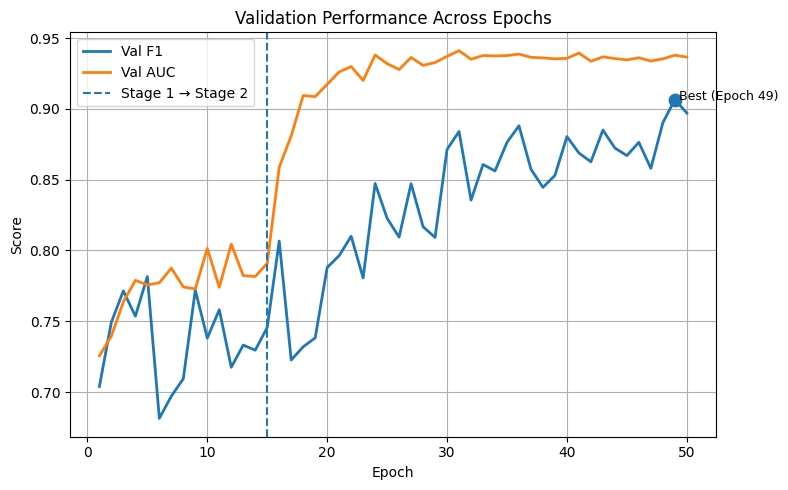

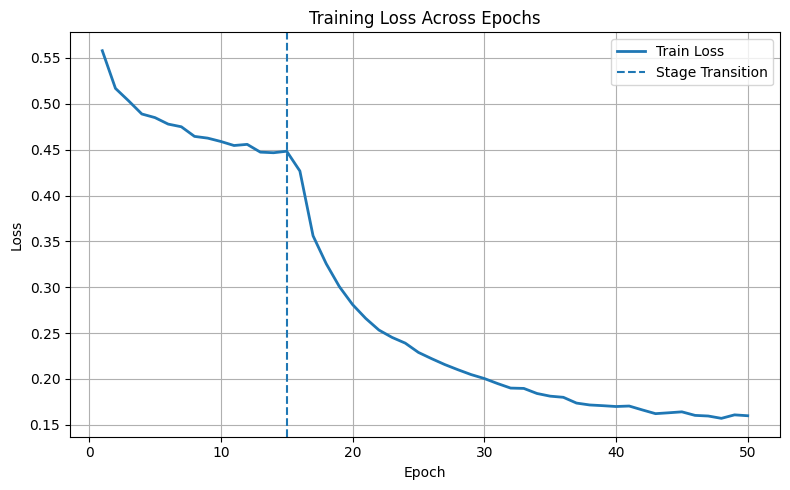

Saved history CSV to: outputs_methodx_final_1\results\training_history.csv
Saved best epoch summary to: outputs_methodx_final_1\results\best_epoch_summary.json
Saved validation curve to: outputs_methodx_final_1\results\figures\training_history.png
Saved training loss curve to: outputs_methodx_final_1\results\figures\training_loss_curve.png


,epoch,stage,train_loss,lr,accuracy,precision,recall,specificity,f1,f1_macro,...,tn,fp,fn,tp,fpr,fnr,eer,auc,pr_auc,loss
45,46,2,0.160292,0.000003,0.837060,0.948465,0.814494,0.892086,0.876389,0.818708,...,1984,240,1006,4417,0.107914,0.185506,0.141126,0.936048,0.969029,0.435794
46,47,2,0.159613,0.000002,0.817052,0.954381,0.779273,0.909173,0.857984,0.800478,...,2022,202,1197,4226,0.090827,0.220727,0.144452,0.933827,0.969027,0.477305
47,48,2,0.157068,0.000001,0.852230,0.941394,0.844182,0.871853,0.890142,0.832251,...,1939,285,845,4578,0.128147,0.155818,0.139714,0.935324,0.966952,0.411841
48,49,2,0.160862,0.000001,0.871061,0.932540,0.881984,0.844424,0.906558,0.849314,...,1878,346,640,4783,0.155576,0.118016,0.135939,0.937883,0.965981,0.375522
49,50,2,0.159905,0.000001,0.860337,0.939633,0.858197,0.865558,0.897070,0.839954,...,1925,299,769,4654,0.134442,0.141803,0.137985,0.936584,0.966952,0.399079


In [49]:
# Save history and plots

history_df = pd.DataFrame(history)

if len(history_df) == 0:
    raise ValueError("History is empty. Training must complete before saving plots.")


# Save tabular history
history_csv_path = OUT_RESULTS / "training_history.csv"
save_df(history_df, history_csv_path)


# Best epoch summary
stage1_end = CONFIG["epochs_stage1"]
best_epoch_idx = history_df["f1"].idxmax()
best_epoch = int(history_df.loc[best_epoch_idx, "epoch"])
best_f1_val = float(history_df.loc[best_epoch_idx, "f1"])

best_epoch_summary = {
    "best_epoch": best_epoch,
    "best_stage": int(history_df.loc[best_epoch_idx, "stage"]),
    "best_f1": best_f1_val,
    "best_auc": float(history_df.loc[best_epoch_idx, "auc"]) if not pd.isna(history_df.loc[best_epoch_idx, "auc"]) else None,
    "best_pr_auc": float(history_df.loc[best_epoch_idx, "pr_auc"]) if not pd.isna(history_df.loc[best_epoch_idx, "pr_auc"]) else None,
    "best_recall": float(history_df.loc[best_epoch_idx, "recall"]) if not pd.isna(history_df.loc[best_epoch_idx, "recall"]) else None,
}

save_json(best_epoch_summary, OUT_RESULTS / "best_epoch_summary.json")


# Validation performance curve
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["f1"], label="Val F1", linewidth=2)
plt.plot(history_df["epoch"], history_df["auc"], label="Val AUC", linewidth=2)
plt.axvline(stage1_end, linestyle="--", linewidth=1.5, label="Stage 1 → Stage 2")
plt.scatter(best_epoch, best_f1_val, s=80)
plt.text(best_epoch, best_f1_val, f" Best (Epoch {best_epoch})", fontsize=9)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance Across Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(ARTIFACTS["training_plot_png"], dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# Training loss curve
training_loss_path = OUT_FIGURES / "training_loss_curve.png"

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", linewidth=2)
plt.axvline(stage1_end, linestyle="--", linewidth=1.5, label="Stage Transition")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(training_loss_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved history CSV to:", history_csv_path)
print("Saved best epoch summary to:", OUT_RESULTS / "best_epoch_summary.json")
print("Saved validation curve to:", ARTIFACTS["training_plot_png"])
print("Saved training loss curve to:", training_loss_path)

display(history_df.tail())

In [50]:
# Load best checkpoint (Stage 2)

ckpt = torch.load(
    best_stage2_checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

best_model = HybridModel(pretrained=False).to(DEVICE)
best_model.load_state_dict(ckpt["model_state"])
best_model.eval()

print("Best epoch:", ckpt["epoch"])
print("Best F1   :", ckpt["best_f1"])
print("Best AUC  :", ckpt["best_auc"])


# Validation evaluation
val_metrics = evaluate_model(
    best_model,
    val_loader,
    criterion=criterion,
    threshold=0.5
)

val_clean = {
    k: v for k, v in val_metrics.items()
    if k not in ["probs", "labels"]
}

print("\n=== VALIDATION (Best Model) ===")
print(val_clean)


# Save
val_metrics_path = OUT_RESULTS / "val_best_metrics.json"
save_json(val_clean, val_metrics_path)

print("Saved validation metrics to:", val_metrics_path)

Best epoch: 49
Best F1   : 0.9065579984836998
Best AUC  : 0.9378831021481913

=== VALIDATION (Best Model) ===
{'accuracy': 0.8710605466195894, 'precision': 0.9325404562292845, 'recall': 0.88198414161903, 'specificity': 0.8444244604316546, 'f1': 0.9065579984836998, 'f1_macro': 0.8493144273312636, 'balanced_accuracy': 0.8632043010253423, 'tn': 1878, 'fp': 346, 'fn': 640, 'tp': 4783, 'fpr': 0.15557553956834533, 'fnr': 0.11801585838096994, 'eer': 0.1359392018010154, 'auc': 0.9378831021481913, 'pr_auc': 0.9659806331088747, 'loss': 0.37552152271830086}
Saved validation metrics to: outputs_methodx_final_1\results\val_best_metrics.json


In [51]:
# Threshold tuning on validation

probs = np.asarray(val_metrics["probs"], dtype=np.float32)
labels = np.asarray(val_metrics["labels"], dtype=np.int32)

threshold_grid = np.linspace(0.05, 0.95, 91)
candidates = []

for t in threshold_grid:
    metrics_t = compute_all_metrics(labels, probs, threshold=float(t))
    candidates.append({
        "threshold": round(float(t), 4),
        "accuracy": float(metrics_t["accuracy"]),
        "precision": float(metrics_t["precision"]),
        "recall": float(metrics_t["recall"]),
        "specificity": float(metrics_t["specificity"]),
        "f1": float(metrics_t["f1"]),
        "f1_macro": float(metrics_t["f1_macro"]),
        "balanced_accuracy": float(metrics_t["balanced_accuracy"]),
        "fpr": float(metrics_t["fpr"]),
        "fnr": float(metrics_t["fnr"]),
        "tn": int(metrics_t["tn"]),
        "fp": int(metrics_t["fp"]),
        "fn": int(metrics_t["fn"]),
        "tp": int(metrics_t["tp"]),
    })

cand_df = pd.DataFrame(candidates)


# Primary constrained selection rule for debug run:
# prefer high-recall operating points suitable for forensic screening
eligible_df = cand_df[
    (cand_df["recall"] >= 0.90) &
    (cand_df["precision"] >= 0.80)
].copy()

if len(eligible_df) > 0:
    eligible_df = eligible_df.sort_values(
        ["f1", "recall", "precision"],
        ascending=False
    ).reset_index(drop=True)

    selected_row = eligible_df.iloc[0]
    best_threshold = float(selected_row["threshold"])
    selection_mode = "constraint_satisfied"

    print("Selected threshold:", best_threshold)
    display(eligible_df.head(20))
else:
    # fallback: select by best F1 across all thresholds
    cand_df = cand_df.sort_values(
        ["f1", "recall", "precision"],
        ascending=False
    ).reset_index(drop=True)

    selected_row = cand_df.iloc[0]
    best_threshold = float(selected_row["threshold"])
    selection_mode = "fallback_best_f1"

    print("No threshold met recall>=0.90 and precision>=0.80.")
    print("Falling back to best F1 threshold:", best_threshold)
    display(cand_df.head(20))


# Save artifacts
threshold_summary = {
    "selected_threshold": best_threshold,
    "selection_mode": selection_mode,
    "selection_constraints": {
        "min_recall": 0.90,
        "min_precision": 0.80
    },
    "selected_metrics": {
        "accuracy": float(selected_row["accuracy"]),
        "precision": float(selected_row["precision"]),
        "recall": float(selected_row["recall"]),
        "specificity": float(selected_row["specificity"]),
        "f1": float(selected_row["f1"]),
        "f1_macro": float(selected_row["f1_macro"]),
        "balanced_accuracy": float(selected_row["balanced_accuracy"]),
        "fpr": float(selected_row["fpr"]),
        "fnr": float(selected_row["fnr"]),
        "tn": int(selected_row["tn"]),
        "fp": int(selected_row["fp"]),
        "fn": int(selected_row["fn"]),
        "tp": int(selected_row["tp"]),
    }
}

save_df(cand_df, OUT_TABLES / "threshold_candidates.csv")
save_json(threshold_summary, ARTIFACTS["thresholds_json"])

print("Saved threshold candidates to:", OUT_TABLES / "threshold_candidates.csv")
print("Saved selected threshold to:", ARTIFACTS["thresholds_json"])

Selected threshold: 0.15


,threshold,accuracy,precision,recall,specificity,f1,f1_macro,balanced_accuracy,fpr,fnr,tn,fp,fn,tp
0,0.15,0.892507,0.902396,0.951318,0.749101,0.926212,0.864165,0.850210,0.250899,0.048682,1666,558,264,5159
1,0.16,0.892507,0.904093,0.949106,0.754496,0.926053,0.864654,0.851801,0.245504,0.050894,1678,546,276,5147
2,0.19,0.892638,0.908849,0.943205,0.769335,0.925708,0.866106,0.856270,0.230665,0.056795,1711,513,308,5115
3,0.14,0.891330,0.899304,0.953531,0.739658,0.925624,0.861987,0.846595,0.260342,0.046469,1645,579,252,5171
4,0.17,0.891984,0.905022,0.947077,0.757644,0.925572,0.864359,0.852361,0.242356,0.052923,1685,539,287,5136
5,0.13,0.890807,0.896337,0.956666,0.730216,0.925520,0.860507,0.843441,0.269784,0.043334,1624,600,235,5188
6,0.18,0.891722,0.906709,0.944496,0.763040,0.925217,0.864551,0.853768,0.236960,0.055504,1697,527,301,5122
7,0.12,0.889630,0.893182,0.959063,0.720324,0.924951,0.858227,0.839693,0.279676,0.040937,1602,622,222,5201
8,0.11,0.888976,0.890140,0.962198,0.710432,0.924767,0.856497,0.836315,0.289568,0.037802,1580,644,205,5218
9,0.20,0.890676,0.909627,0.939148,0.772482,0.924152,0.864229,0.855815,0.227518,0.060852,1718,506,330,5093


Saved threshold candidates to: outputs_methodx_final_1\results\tables\threshold_candidates.csv
Saved selected threshold to: outputs_methodx_final_1\results\thresholds.json


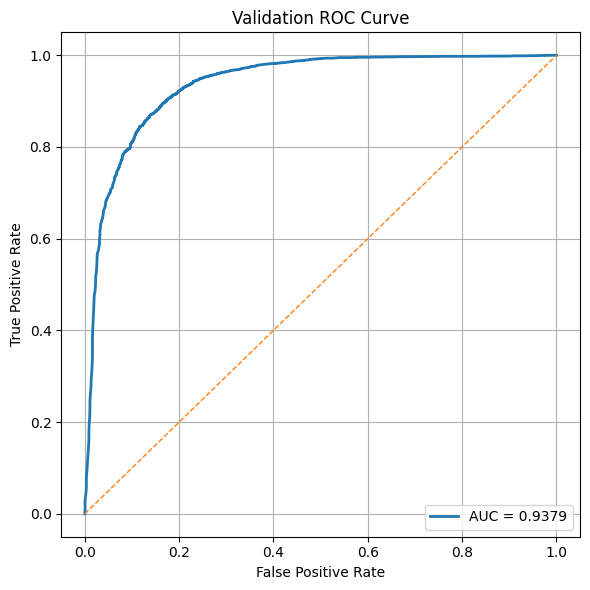

In [52]:
# Validation ROC curve

fpr, tpr, _ = roc_curve(val_metrics["labels"], val_metrics["probs"])
val_auc = roc_auc_score(val_metrics["labels"], val_metrics["probs"])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {val_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(ARTIFACTS["val_roc_png"], dpi=300, bbox_inches="tight")
plt.show()
plt.close()

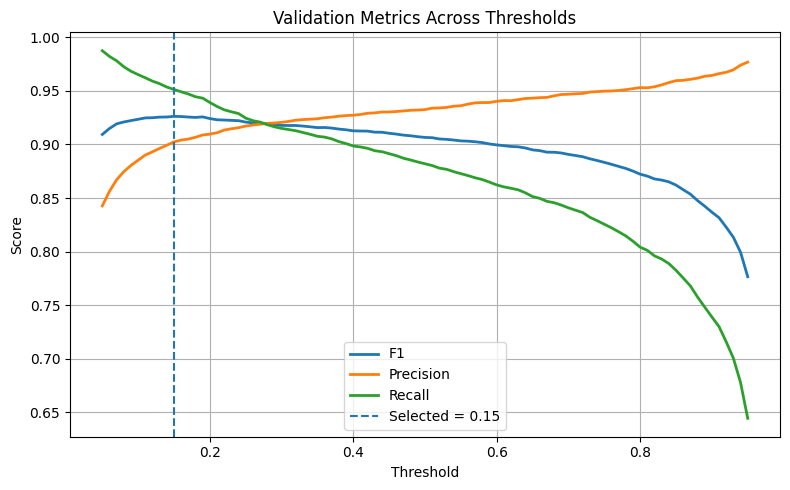

In [55]:
# Threshold curves

thr_df = pd.read_csv(OUT_TABLES / "threshold_candidates.csv")

plt.figure(figsize=(8, 5))
plt.plot(thr_df["threshold"], thr_df["f1"], label="F1", linewidth=2)
plt.plot(thr_df["threshold"], thr_df["precision"], label="Precision", linewidth=2)
plt.plot(thr_df["threshold"], thr_df["recall"], label="Recall", linewidth=2)
plt.axvline(best_threshold, linestyle="--", linewidth=1.5, label=f"Selected = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Metrics Across Thresholds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_FIGURES / "threshold_metric_curves.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
# Test inference latency

best_model.eval()
n_samples = 0
start = time.time()

with torch.no_grad():
    for batch in test_loader:
        images = batch[0].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda" and CONFIG["amp"])):
            _ = best_model(images)
        n_samples += images.size(0)

elapsed = time.time() - start
latency_summary = {
    "num_samples": n_samples,
    "total_inference_time_sec": elapsed,
    "ms_per_sample": 1000.0 * elapsed / max(n_samples, 1)
}

save_json(latency_summary, OUT_RESULTS / "test_latency.json")
print(latency_summary)

{'num_samples': 7644, 'total_inference_time_sec': 98.94365644454956, 'ms_per_sample': 12.943963428120037}


In [56]:
# Test inference latency

best_model.eval()
n_samples = 0
start = time.time()

with torch.no_grad():
    for batch in test_loader:
        images = batch[0].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda" and CONFIG["amp"])):
            _ = best_model(images)
        n_samples += images.size(0)

elapsed = time.time() - start
latency_summary = {
    "num_samples": n_samples,
    "total_inference_time_sec": elapsed,
    "ms_per_sample": 1000.0 * elapsed / max(n_samples, 1)
}

save_json(latency_summary, OUT_RESULTS / "test_latency.json")
print(latency_summary)

{'num_samples': 7644, 'total_inference_time_sec': 98.94365644454956, 'ms_per_sample': 12.943963428120037}


In [57]:
# Final threshold-aware validation + overall test evaluation

val_selected_metrics = compute_all_metrics(
    val_metrics["labels"],
    val_metrics["probs"],
    threshold=best_threshold
)

test_metrics = evaluate_model(
    best_model,
    test_loader,
    criterion=criterion,
    threshold=best_threshold
)

val_selected_clean = {
    k: v for k, v in val_selected_metrics.items()
    if k not in ["probs", "labels"]
}
test_summary = {
    k: v for k, v in test_metrics.items()
    if k not in ["probs", "labels"]
}

final_eval_summary = {
    "selected_threshold": float(best_threshold),
    "validation_metrics_at_selected_threshold": val_selected_clean,
    "test_metrics_at_selected_threshold": test_summary,
}

save_json(final_eval_summary, OUT_RESULTS / "final_thresholded_evaluation.json")
save_json(test_summary, ARTIFACTS["test_metrics_json"])
save_df(pd.DataFrame([test_summary]), ARTIFACTS["overall_test_csv"])

print("Selected threshold:", best_threshold)
print("\n=== TEST (selected threshold) ===")
print(test_summary)

print("\nSaved final thresholded evaluation to:", OUT_RESULTS / "final_thresholded_evaluation.json")
print("Saved test metrics JSON to:", ARTIFACTS["test_metrics_json"])
print("Saved overall test CSV to:", ARTIFACTS["overall_test_csv"])

Selected threshold: 0.15

=== TEST (selected threshold) ===
{'accuracy': 0.8835688121402407, 'precision': 0.8959972032861387, 'recall': 0.9455819959417082, 'specificity': 0.7323436797121008, 'f1': 0.9201220606713337, 'f1_macro': 0.8527286617876688, 'balanced_accuracy': 0.8389628378269045, 'tn': 1628, 'fp': 595, 'fn': 295, 'tp': 5126, 'fpr': 0.2676563202878992, 'fnr': 0.05441800405829183, 'eer': 0.14633313592041344, 'auc': 0.9228658182143167, 'pr_auc': 0.9516001021000723, 'loss': 0.40134415535762136}

Saved final thresholded evaluation to: outputs_methodx_final_1\results\final_thresholded_evaluation.json
Saved test metrics JSON to: outputs_methodx_final_1\results\test_metrics.json
Saved overall test CSV to: outputs_methodx_final_1\results\tables\overall_test_metrics.csv


In [58]:
# Per-domain test evaluation

def seed_worker(worker_id):
    worker_seed = CONFIG["seed"] + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def evaluate_manifest_subset(model, df_subset, domain_name, threshold):
    ds = ManifestDataset(
        df=df_subset,
        split="test",
        domain_name=domain_name,
        return_path=False
    )

    generator = torch.Generator()
    generator.manual_seed(CONFIG["seed"])

    loader_kwargs = dict(
        batch_size=CONFIG["batch_size"] * 2,
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=CONFIG["pin_memory"],
        persistent_workers=(CONFIG["num_workers"] > 0 and CONFIG["persistent_workers"]),
        worker_init_fn=seed_worker,
        generator=generator,
    )
    if CONFIG["num_workers"] > 0:
        loader_kwargs["prefetch_factor"] = CONFIG["prefetch_factor"]

    loader = DataLoader(ds, **loader_kwargs)
    metrics = evaluate_model(model, loader, criterion=criterion, threshold=threshold)
    clean_metrics = {k: v for k, v in metrics.items() if k not in ["probs", "labels"]}
    clean_metrics["domain"] = domain_name
    clean_metrics["total"] = len(ds)
    return clean_metrics


# Load all manifests and restrict to test split
manifest_paths = [
    OUT_MANIFESTS / "ffpp_manifest.csv",
    OUT_MANIFESTS / "celebdf_manifest.csv",
    OUT_MANIFESTS / "gan_manifest.csv",
]

all_df = pd.concat([pd.read_csv(p) for p in manifest_paths], ignore_index=True)
test_df = all_df[all_df["split"] == "test"].copy()


# Family-level evaluation
family_groups = {
    "FF++": test_df[test_df["domain"].str.startswith("ffpp_")].copy(),
    "Celeb-DF": test_df[test_df["domain"].str.startswith("celebdf_")].copy(),
    "GAN": test_df[test_df["domain"].isin(["ffhq_real", "stylegan_fake"])].copy(),
}

domain_results = []
for domain_name, df_subset in family_groups.items():
    if len(df_subset) == 0:
        continue
    result = evaluate_manifest_subset(best_model, df_subset, domain_name, best_threshold)
    domain_results.append(result)


# Optional subdomain-level evaluation for diagnostic reporting
subdomain_results = []
for subdomain_name in sorted(test_df["domain"].unique()):
    df_subset = test_df[test_df["domain"] == subdomain_name].copy()
    if len(df_subset) == 0:
        continue
    result = evaluate_manifest_subset(best_model, df_subset, subdomain_name, best_threshold)
    subdomain_results.append(result)

domain_df = pd.DataFrame(domain_results)
subdomain_df = pd.DataFrame(subdomain_results)

print("=== Family-level test results ===")
display(domain_df)

print("=== Subdomain-level test results ===")
display(subdomain_df)

save_df(domain_df, ARTIFACTS["per_domain_test_csv"])
save_df(subdomain_df, OUT_TABLES / "per_subdomain_test_metrics.csv")

print("Saved family-level results to:", ARTIFACTS["per_domain_test_csv"])
print("Saved subdomain-level results to:", OUT_TABLES / "per_subdomain_test_metrics.csv")

[FF++ | test] samples=4797 (real=800, fake=3997)
[Celeb-DF | test] samples=1423 (real=711, fake=712)
[GAN | test] samples=1424 (real=712, fake=712)
[celebdf_fake | test] samples=712 (real=0, fake=712)
[celebdf_real | test] samples=711 (real=711, fake=0)
[ffhq_real | test] samples=712 (real=712, fake=0)
[ffpp_deepfakes | test] samples=800 (real=0, fake=800)
[ffpp_face2face | test] samples=799 (real=0, fake=799)
[ffpp_faceshifter | test] samples=799 (real=0, fake=799)
[ffpp_faceswap | test] samples=799 (real=0, fake=799)
[ffpp_neuraltextures | test] samples=800 (real=0, fake=800)
[ffpp_real | test] samples=800 (real=800, fake=0)
[stylegan_fake | test] samples=712 (real=0, fake=712)
=== Family-level test results ===


,accuracy,precision,recall,specificity,f1,f1_macro,balanced_accuracy,tn,fp,fn,tp,fpr,fnr,eer,auc,pr_auc,loss,domain,total
0,0.850532,0.894990,0.929697,0.455000,0.912014,0.707910,0.692349,364,436,281,3716,0.545000,0.070303,0.252595,0.809677,0.941736,0.517617,FF++,4797
1,0.878426,0.814469,0.980337,0.776371,0.889739,0.877132,0.878354,552,159,14,698,0.223629,0.019663,0.066761,0.971082,0.965707,0.292979,Celeb-DF,1423
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,712,0,0,712,0.000000,0.000000,0.000000,1.000000,1.000000,0.117945,GAN,1424


=== Subdomain-level test results ===


,accuracy,precision,recall,specificity,f1,f1_macro,balanced_accuracy,tn,fp,fn,tp,fpr,fnr,eer,auc,pr_auc,loss,domain,total
0,0.980337,1.0,0.980337,0.000000,0.990071,0.495035,0.490169,0,0,14,698,0.000000,0.019663,NaN,NaN,NaN,0.202398,celebdf_fake,712
1,0.776371,0.0,0.000000,0.776371,0.000000,0.437055,0.388186,552,159,0,0,0.223629,0.000000,NaN,NaN,NaN,0.383691,celebdf_real,711
2,1.000000,0.0,0.000000,1.000000,0.000000,1.000000,0.500000,712,0,0,0,0.000000,0.000000,NaN,NaN,NaN,0.117780,ffhq_real,712
3,0.975000,1.0,0.975000,0.000000,0.987342,0.493671,0.487500,0,0,20,780,0.000000,0.025000,NaN,NaN,NaN,0.254029,ffpp_deepfakes,800
4,0.944931,1.0,0.944931,0.000000,0.971686,0.485843,0.472466,0,0,44,755,0.000000,0.055069,NaN,NaN,NaN,0.406023,ffpp_face2face,799
5,0.948686,1.0,0.948686,0.000000,0.973667,0.486834,0.474343,0,0,41,758,0.000000,0.051314,NaN,NaN,NaN,0.363009,ffpp_faceshifter,799
6,0.944931,1.0,0.944931,0.000000,0.971686,0.485843,0.472466,0,0,44,755,0.000000,0.055069,NaN,NaN,NaN,0.350289,ffpp_faceswap,799
7,0.835000,1.0,0.835000,0.000000,0.910082,0.455041,0.417500,0,0,132,668,0.000000,0.165000,NaN,NaN,NaN,0.744958,ffpp_neuraltextures,800
8,0.455000,0.0,0.000000,0.455000,0.000000,0.312715,0.227500,364,436,0,0,0.545000,0.000000,NaN,NaN,NaN,0.986850,ffpp_real,800
9,1.000000,1.0,1.000000,0.000000,1.000000,1.000000,0.500000,0,0,0,712,0.000000,0.000000,NaN,NaN,NaN,0.118111,stylegan_fake,712


Saved family-level results to: outputs_methodx_final_1\results\tables\per_domain_test_metrics.csv
Saved subdomain-level results to: outputs_methodx_final_1\results\tables\per_subdomain_test_metrics.csv


In [ ]:
# Test inference latency

best_model.eval()
n_samples = 0
start = time.time()

with torch.no_grad():
    for batch in test_loader:
        images = batch[0].to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda" and CONFIG["amp"])):
            _ = best_model(images)
        n_samples += images.size(0)

elapsed = time.time() - start
latency_summary = {
    "num_samples": n_samples,
    "total_inference_time_sec": elapsed,
    "ms_per_sample": 1000.0 * elapsed / max(n_samples, 1)
}

save_json(latency_summary, OUT_RESULTS / "test_latency.json")
print(latency_summary)

{'num_samples': 7644, 'total_inference_time_sec': 98.94365644454956, 'ms_per_sample': 12.943963428120037}


In [60]:
# Save final result package

# Read threshold selection info if available
threshold_meta = {}
if ARTIFACTS["thresholds_json"].exists():
    with open(ARTIFACTS["thresholds_json"], "r", encoding="utf-8") as f:
        threshold_meta = json.load(f)

final_metadata = {
    "run_mode": "debug" if CONFIG.get("debug_mode", False) else "paper",
    "device": str(DEVICE),
    "batch_size": int(CONFIG["batch_size"]),
    "epochs_stage1": int(CONFIG["epochs_stage1"]),
    "epochs_stage2": int(CONFIG["epochs_stage2"]),
    "frames_per_video": int(CONFIG["frames_per_video"]),
    "selected_threshold": float(best_threshold),
    "threshold_selection_mode": threshold_meta.get("selection_mode", "unknown"),
    "threshold_constraints": threshold_meta.get("selection_constraints", {}),
    "best_stage1_checkpoint": str(best_stage1_checkpoint_path),
    "best_stage2_checkpoint": str(best_stage2_checkpoint_path),
    "stage1_history_json": str(ARTIFACTS["stage1_history_json"]),
    "stage2_history_json": str(ARTIFACTS["stage2_history_json"]),
    "validation_metrics_json": str(OUT_RESULTS / "val_best_metrics.json"),
    "test_metrics_json": str(ARTIFACTS["test_metrics_json"]),
    "overall_test_csv": str(ARTIFACTS["overall_test_csv"]),
    "per_domain_test_csv": str(ARTIFACTS["per_domain_test_csv"]),
    "training_curve_png": str(ARTIFACTS["training_plot_png"]),
    "config_json": str(ARTIFACTS["config_json"]),
}

save_json(final_metadata, OUT_RESULTS / "final_metadata.json")

combined_df = domain_df.copy()
combined_df["type"] = "domain"

overall_df = pd.DataFrame([test_summary])
overall_df["type"] = "overall"

final_df = pd.concat([combined_df, overall_df], ignore_index=True)
save_df(final_df, OUT_TABLES / "final_results_combined.csv")

with open(OUT_RESULTS / "model_summary.txt", "w", encoding="utf-8") as f:
    f.write(str(best_model))

print("Saved final metadata to:", OUT_RESULTS / "final_metadata.json")
print("Saved combined final results to:", OUT_TABLES / "final_results_combined.csv")
print("Saved model summary to:", OUT_RESULTS / "model_summary.txt")
print("Saved final result package to:", OUT_RESULTS)

Saved final metadata to: outputs_methodx_final_1\results\final_metadata.json
Saved combined final results to: outputs_methodx_final_1\results\tables\final_results_combined.csv
Saved model summary to: outputs_methodx_final_1\results\model_summary.txt
Saved final result package to: outputs_methodx_final_1\results


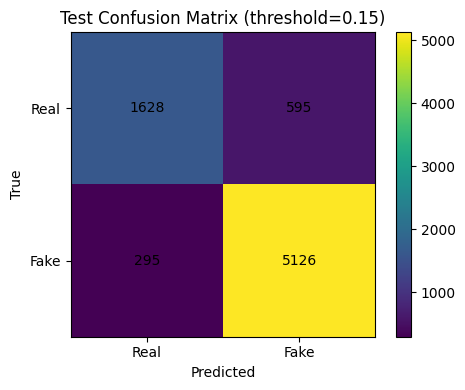

In [62]:
# Test confusion matrix

cm = confusion_matrix(
    test_metrics["labels"],
    (test_metrics["probs"] >= best_threshold).astype(int),
    labels=[0, 1]
)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Test Confusion Matrix (threshold={best_threshold:.2f})")
plt.colorbar()
plt.xticks([0, 1], ["Real", "Fake"])
plt.yticks([0, 1], ["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig(ARTIFACTS["confusion_matrix_png"], dpi=300, bbox_inches="tight")
plt.show()
plt.close()

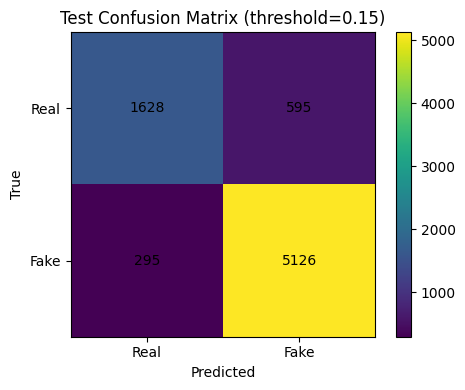

In [63]:
# Test confusion matrix

cm = confusion_matrix(
    test_metrics["labels"],
    (test_metrics["probs"] >= best_threshold).astype(int),
    labels=[0, 1]
)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Test Confusion Matrix (threshold={best_threshold:.2f})")
plt.colorbar()
plt.xticks([0, 1], ["Real", "Fake"])
plt.yticks([0, 1], ["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig(ARTIFACTS["confusion_matrix_png"], dpi=300, bbox_inches="tight")
plt.show()
plt.close()

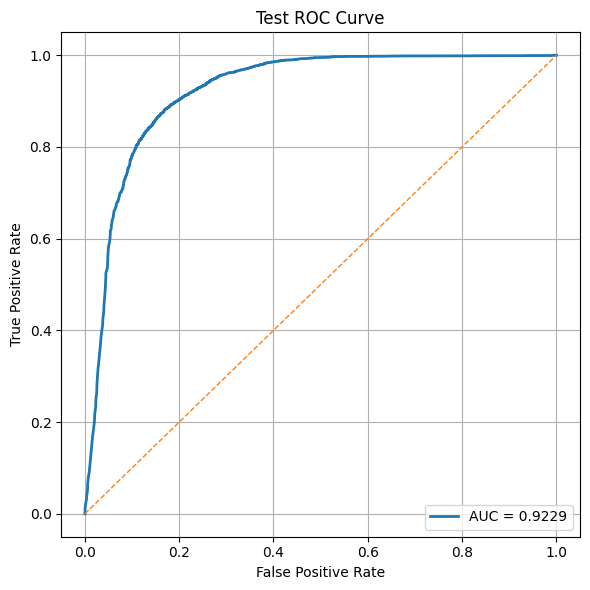

In [64]:
# Test ROC curve

fpr, tpr, _ = roc_curve(test_metrics["labels"], test_metrics["probs"])
test_auc = roc_auc_score(test_metrics["labels"], test_metrics["probs"])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(ARTIFACTS["test_roc_png"], dpi=300, bbox_inches="tight")
plt.show()
plt.close()